# ProtoProperty 2b: Central Members - within category attribute frequencies

### TODO:
- #### Heatmap Plot the number of common attributes between items in the same category & model
- #### Heatmap Plot of the number of overall outputted attributes per item in the same category & model

In [ ]:
# Setup
import pandas as pd
import csv
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import ast
import numpy as np
from collections import defaultdict
from matplotlib.ticker import MaxNLocator
from scipy.stats import pearsonr
from matplotlib.cm import get_cmap

In [2]:
# Import Data

attributes_df  = pd.read_csv('01_catmemexp_attributestask_allmodels_processed_3.csv', dtype=str, quoting=csv.QUOTE_ALL, encoding = "utf-8")
attributes_df.head()

,model,prompt,prompt_id,runtime,category,frequency,item,output,output_list,output_list_processed,output_list_processed_nonoise
0,Qwen2.5-7B-Instruct,\r\n Write all of the attributes of...,6,1.510128021,Furniture,least_frequent,cabinet,"storative,wooden,rectangular,storage,furniture...","['storative', 'wooden', 'rectangular', 'storag...","['storative', 'wooden', 'rectangular', 'storag...","['storative', 'wooden', 'rectangular', 'storag..."
1,Qwen2.5-7B-Instruct,\r\n Write all of the attributes of...,6,1.499021292,Furniture,most_frequent,desk,"flat,wooden,rectangular,surface,functional,off...","['flat', 'wooden', 'rectangular', 'surface', '...","['flat', 'wooden', 'rectangular', 'surface', '...","['flat', 'wooden', 'rectangular', 'surface', '..."
2,Qwen2.5-7B-Instruct,\r\n Write all of the attributes of...,6,1.223744392,Furniture,least_frequent,patio set,"comfortable,durable,functional,outdoor,spaciou...","['comfortable', 'durable', 'functional', 'outd...","['comfortable', 'durable', 'functional', 'outd...","['comfortable', 'durable', 'functional', 'outd..."
3,Qwen2.5-7B-Instruct,\r\n Write all of the attributes of...,6,1.331822634,Furniture,most_frequent,dresser,"wooden,tall,narrow,drawers,shelves,storage,dec...","['wooden', 'tall', 'narrow', 'drawers', 'shelv...","['wooden', 'tall', 'narrow', 'drawers', 'shelv...","['wooden', 'tall', 'drawers', 'storage', 'deco..."
4,Qwen2.5-7B-Instruct,\r\n Write all of the attributes of...,6,1.826406479,Furniture,most_frequent,bookshelf,"wooden,tall,wide,sturdy,rectangular,horizontal...","['wooden', 'tall', 'wide', 'sturdy', 'rectangu...","['wooden', 'tall', 'wide', 'sturdy', 'rectangu...","['wooden', 'tall', 'wide', 'sturdy', 'rectangu..."


In [3]:
attributes_df['output_list_processed_nonoise'] = attributes_df['output_list_processed_nonoise'].apply(ast.literal_eval)

In [ ]:
# Counting for each attribute in each category and for each model how many items it applies to

models = attributes_df['model'].unique() 
categories = attributes_df['category'].unique()

final_dataframes = []

for model in models:
    for category in categories:
        
        filtered_df = attributes_df[(attributes_df['category'] == category) & (attributes_df['model'] == model)]

        exploded_attrs = filtered_df.explode('output_list_processed_nonoise')

        attribute_counts = exploded_attrs.groupby('output_list_processed_nonoise')['item'].nunique().reset_index()
        attribute_counts.columns = ['attribute', 'score']

        model_category_df = pd.DataFrame({
            'model': model,
            'category': category,
            'attribute': attribute_counts['attribute'],
            'score': attribute_counts['score']
        })

        final_dataframes.append(model_category_df)

final_df = pd.concat(final_dataframes, ignore_index=True)

final_df


,model,category,attribute,score
0,Qwen2.5-7B-Instruct,Furniture,adjustable,1
1,Qwen2.5-7B-Instruct,Furniture,armrests,1
2,Qwen2.5-7B-Instruct,Furniture,bed,1
3,Qwen2.5-7B-Instruct,Furniture,bedroom,2
4,Qwen2.5-7B-Instruct,Furniture,bedside,2
...,...,...,...,...
14933,deepseek-chat,Clothing,wrap-around,1
14934,deepseek-chat,Clothing,wrapped,1
14935,deepseek-chat,Clothing,zip-up,1
14936,deepseek-chat,Clothing,zipper-fly,1


In [ ]:
# Collecting unique attributes per item

models = attributes_df['model'].unique()  
categories = attributes_df['category'].unique()

result_rows = []

for model in models:
    for category in categories:
        filtered_df = attributes_df[(attributes_df['category'] == category) & (attributes_df['model'] == model)]

        grouped_df = filtered_df.groupby('item')['output_list_processed_nonoise'].agg(lambda x: set(attr for sublist in x for attr in sublist)).reset_index()

        for _, row in grouped_df.iterrows():
            result_row = {
                'model': model,
                'category': category,
                'item': row['item'],
                'attributes': list(row['output_list_processed_nonoise'])
            }
            result_rows.append(result_row)

unique_attributes_df = pd.DataFrame(result_rows)

unique_attributes_df


,model,category,item,attributes
0,Qwen2.5-7B-Instruct,Furniture,armchair,"[spacious, reclining, upholstered, ergonomic, ..."
1,Qwen2.5-7B-Instruct,Furniture,bookshelf,"[spacious, sturdy, tall, organized, rectangula..."
2,Qwen2.5-7B-Instruct,Furniture,bunk bed,"[multi-level, tiered, bed, supportive, sleepin..."
3,Qwen2.5-7B-Instruct,Furniture,cabinet,"[multi-compartment, fixed, rectangular, wooden..."
4,Qwen2.5-7B-Instruct,Furniture,chair,"[sturdy, four-legged, upholstered, ergonomic, ..."
...,...,...,...,...
932,deepseek-chat,Clothing,purse,"[expensive, gift, old, lost, vintage, unisex, ..."
933,deepseek-chat,Clothing,sandal,"[plastic, airy, beach, footwear, practical, co..."
934,deepseek-chat,Clothing,sock,"[diabetic, slipper, layered, patched, stained,..."
935,deepseek-chat,Clothing,t-shirt,"[pre-shrunk, vintage, comfortable, solid, athl..."


In [ ]:
# Creating each item's attribute's score vector (based on attribute frequency in final_df) per item per category per model

unique_attributes_df['attribute_scores'] = None

for index, row in unique_attributes_df.iterrows():

    model = row['model']
    category = row['category']
    item = row['item']
    attributes = row['attributes']

    scores = []

    for attribute in attributes:

        score = final_df[(final_df['model'] == model) & 
                         (final_df['category'] == category) & 
                         (final_df['attribute'] == attribute)]['score']

        if not score.empty:
            scores.append(score.values[0])
        else:
            scores.append(0)

    unique_attributes_df.at[index, 'attribute_scores'] = scores

unique_attributes_df



,model,category,item,attributes,attribute_scores
0,Qwen2.5-7B-Instruct,Furniture,armchair,"[spacious, reclining, upholstered, ergonomic, ...","[4, 2, 4, 3, 13, 5, 3, 3, 1, 6]"
1,Qwen2.5-7B-Instruct,Furniture,bookshelf,"[spacious, sturdy, tall, organized, rectangula...","[4, 6, 2, 2, 9, 13, 5, 1, 1, 1, 1, 1, 6]"
2,Qwen2.5-7B-Instruct,Furniture,bunk bed,"[multi-level, tiered, bed, supportive, sleepin...","[3, 1, 1, 2, 1, 13, 1, 3, 1, 1, 1]"
3,Qwen2.5-7B-Instruct,Furniture,cabinet,"[multi-compartment, fixed, rectangular, wooden...","[1, 1, 9, 13, 5, 1, 2, 1, 3, 2, 2, 6]"
4,Qwen2.5-7B-Instruct,Furniture,chair,"[sturdy, four-legged, upholstered, ergonomic, ...","[6, 1, 4, 3, 2, 3, 13, 5, 3, 1, 6, 7]"
...,...,...,...,...,...
932,deepseek-chat,Clothing,purse,"[expensive, gift, old, lost, vintage, unisex, ...","[2, 2, 2, 2, 3, 2, 1, 1, 1, 2, 4, 1, 4, 1, 4, ..."
933,deepseek-chat,Clothing,sandal,"[plastic, airy, beach, footwear, practical, co...","[1, 2, 1, 1, 4, 7, 12, 8, 1, 1, 5, 3, 1, 1, 2,..."
934,deepseek-chat,Clothing,sock,"[diabetic, slipper, layered, patched, stained,...","[1, 1, 3, 2, 1, 1, 1, 12, 1, 1, 1, 1, 2, 1, 1,..."
935,deepseek-chat,Clothing,t-shirt,"[pre-shrunk, vintage, comfortable, solid, athl...","[1, 3, 7, 2, 3, 2, 7, 8, 5, 1, 3, 4, 12, 1, 8,..."


In [ ]:
# Calculating Family Resemblance Measures

unique_attributes_df['basic_measure'] = unique_attributes_df['attribute_scores'].apply(sum)

unique_attributes_df['log_measure'] = unique_attributes_df['attribute_scores'].apply(
    lambda scores: sum(np.log(score) for score in scores if score > 0))

unique_attributes_df

,model,category,item,attributes,attribute_scores,basic_measure,log_measure
0,Qwen2.5-7B-Instruct,Furniture,armchair,"[spacious, reclining, upholstered, ergonomic, ...","[4, 2, 4, 3, 13, 5, 3, 3, 1, 6]",44,12.727720
1,Qwen2.5-7B-Instruct,Furniture,bookshelf,"[spacious, sturdy, tall, organized, rectangula...","[4, 6, 2, 2, 9, 13, 5, 1, 1, 1, 1, 1, 6]",52,12.727720
2,Qwen2.5-7B-Instruct,Furniture,bunk bed,"[multi-level, tiered, bed, supportive, sleepin...","[3, 1, 1, 2, 1, 13, 1, 3, 1, 1, 1]",28,5.455321
3,Qwen2.5-7B-Instruct,Furniture,cabinet,"[multi-compartment, fixed, rectangular, wooden...","[1, 1, 9, 13, 5, 1, 2, 1, 3, 2, 2, 6]",46,11.341425
4,Qwen2.5-7B-Instruct,Furniture,chair,"[sturdy, four-legged, upholstered, ergonomic, ...","[6, 1, 4, 3, 2, 3, 13, 5, 3, 1, 6, 7]",54,15.079095
...,...,...,...,...,...,...,...
932,deepseek-chat,Clothing,purse,"[expensive, gift, old, lost, vintage, unisex, ...","[2, 2, 2, 2, 3, 2, 1, 1, 1, 2, 4, 1, 4, 1, 4, ...",188,50.691613
933,deepseek-chat,Clothing,sandal,"[plastic, airy, beach, footwear, practical, co...","[1, 2, 1, 1, 4, 7, 12, 8, 1, 1, 5, 3, 1, 1, 2,...",71,17.232644
934,deepseek-chat,Clothing,sock,"[diabetic, slipper, layered, patched, stained,...","[1, 1, 3, 2, 1, 1, 1, 12, 1, 1, 1, 1, 2, 1, 1,...",249,56.845197
935,deepseek-chat,Clothing,t-shirt,"[pre-shrunk, vintage, comfortable, solid, athl...","[1, 3, 7, 2, 3, 2, 7, 8, 5, 1, 3, 4, 12, 1, 8,...",128,36.049653


In [ ]:
# Import items_df and calculate frequency of each item in the table

items_df = pd.read_csv('01_catmemexp_itemstask_allmodels_processed.csv', dtype=str, quoting=csv.QUOTE_ALL, encoding="utf-8")
items_df['output_list_processed_nonoise'] = items_df['output_list_processed_nonoise'].apply(ast.literal_eval)

model_items = items_df.explode('output_list_processed_nonoise')

item_counts = model_items.groupby(['model', 'category', 'output_list_processed_nonoise']).size().reset_index(name='frequency')

item_counts.rename(columns={'output_list_processed_nonoise': 'item'}, inplace=True)

filtered_item_counts = item_counts[~item_counts['category'].isin(["Bird", "Carpenter's tool", "Toy","Sport"])]

filtered_item_counts

,model,category,item,frequency
78,Meta-Llama-3.1-70B-Instruct,Clothing,apron,4
79,Meta-Llama-3.1-70B-Instruct,Clothing,belt,20
80,Meta-Llama-3.1-70B-Instruct,Clothing,blouse,18
81,Meta-Llama-3.1-70B-Instruct,Clothing,boot,30
82,Meta-Llama-3.1-70B-Instruct,Clothing,bra,27
...,...,...,...,...
14850,gpt-5.2,Weapon,truncheon,3
14851,gpt-5.2,Weapon,war pick,2
14852,gpt-5.2,Weapon,warhammer,15
14853,gpt-5.2,Weapon,warhead,2


In [ ]:
for df in [filtered_item_counts]:
    df['model'] = df['model'].str.strip()
    df['category'] = df['category'].str.strip()
    df['item'] = df['item'].str.strip()

unique_attributes_df['frequency'] = None  

for idx, row in unique_attributes_df.iterrows():
    model = row['model']
    category = row['category']
    item = row['item']

    freq = filtered_item_counts.loc[
        (filtered_item_counts['model'] == model) &
        (filtered_item_counts['category'] == category) &
        (filtered_item_counts['item'] == item), 
        'frequency']

    if not freq.empty:
        unique_attributes_df.at[idx, 'frequency'] = freq.values[0]

unique_attributes_df

C:\Users\AS\AppData\Local\Temp\ipykernel_20000\2001697046.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['model'] = df['model'].str.strip()
C:\Users\AS\AppData\Local\Temp\ipykernel_20000\2001697046.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['category'] = df['category'].str.strip()
C:\Users\AS\AppData\Local\Temp\ipykernel_20000\2001697046.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instea

,model,category,item,attributes,attribute_scores,basic_measure,log_measure,frequency
0,Qwen2.5-7B-Instruct,Furniture,armchair,"[spacious, reclining, upholstered, ergonomic, ...","[4, 2, 4, 3, 13, 5, 3, 3, 1, 6]",44,12.727720,22
1,Qwen2.5-7B-Instruct,Furniture,bookshelf,"[spacious, sturdy, tall, organized, rectangula...","[4, 6, 2, 2, 9, 13, 5, 1, 1, 1, 1, 1, 6]",52,12.727720,29
2,Qwen2.5-7B-Instruct,Furniture,bunk bed,"[multi-level, tiered, bed, supportive, sleepin...","[3, 1, 1, 2, 1, 13, 1, 3, 1, 1, 1]",28,5.455321,9
3,Qwen2.5-7B-Instruct,Furniture,cabinet,"[multi-compartment, fixed, rectangular, wooden...","[1, 1, 9, 13, 5, 1, 2, 1, 3, 2, 2, 6]",46,11.341425,8
4,Qwen2.5-7B-Instruct,Furniture,chair,"[sturdy, four-legged, upholstered, ergonomic, ...","[6, 1, 4, 3, 2, 3, 13, 5, 3, 1, 6, 7]",54,15.079095,30
...,...,...,...,...,...,...,...,...
932,deepseek-chat,Clothing,purse,"[expensive, gift, old, lost, vintage, unisex, ...","[2, 2, 2, 2, 3, 2, 1, 1, 1, 2, 4, 1, 4, 1, 4, ...",188,50.691613,15
933,deepseek-chat,Clothing,sandal,"[plastic, airy, beach, footwear, practical, co...","[1, 2, 1, 1, 4, 7, 12, 8, 1, 1, 5, 3, 1, 1, 2,...",71,17.232644,30
934,deepseek-chat,Clothing,sock,"[diabetic, slipper, layered, patched, stained,...","[1, 1, 3, 2, 1, 1, 1, 12, 1, 1, 1, 1, 2, 1, 1,...",249,56.845197,30
935,deepseek-chat,Clothing,t-shirt,"[pre-shrunk, vintage, comfortable, solid, athl...","[1, 3, 7, 2, 3, 2, 7, 8, 5, 1, 3, 4, 12, 1, 8,...",128,36.049653,30


In [10]:
unique_attributes_df.dropna(inplace=True)

#save results_df
unique_attributes_df.to_csv('famres_scores_df.csv', index=False)

unique_attributes_df

,model,category,item,attributes,attribute_scores,basic_measure,log_measure,frequency
0,Qwen2.5-7B-Instruct,Furniture,armchair,"[spacious, reclining, upholstered, ergonomic, ...","[4, 2, 4, 3, 13, 5, 3, 3, 1, 6]",44,12.727720,22
1,Qwen2.5-7B-Instruct,Furniture,bookshelf,"[spacious, sturdy, tall, organized, rectangula...","[4, 6, 2, 2, 9, 13, 5, 1, 1, 1, 1, 1, 6]",52,12.727720,29
2,Qwen2.5-7B-Instruct,Furniture,bunk bed,"[multi-level, tiered, bed, supportive, sleepin...","[3, 1, 1, 2, 1, 13, 1, 3, 1, 1, 1]",28,5.455321,9
3,Qwen2.5-7B-Instruct,Furniture,cabinet,"[multi-compartment, fixed, rectangular, wooden...","[1, 1, 9, 13, 5, 1, 2, 1, 3, 2, 2, 6]",46,11.341425,8
4,Qwen2.5-7B-Instruct,Furniture,chair,"[sturdy, four-legged, upholstered, ergonomic, ...","[6, 1, 4, 3, 2, 3, 13, 5, 3, 1, 6, 7]",54,15.079095,30
...,...,...,...,...,...,...,...,...
932,deepseek-chat,Clothing,purse,"[expensive, gift, old, lost, vintage, unisex, ...","[2, 2, 2, 2, 3, 2, 1, 1, 1, 2, 4, 1, 4, 1, 4, ...",188,50.691613,15
933,deepseek-chat,Clothing,sandal,"[plastic, airy, beach, footwear, practical, co...","[1, 2, 1, 1, 4, 7, 12, 8, 1, 1, 5, 3, 1, 1, 2,...",71,17.232644,30
934,deepseek-chat,Clothing,sock,"[diabetic, slipper, layered, patched, stained,...","[1, 1, 3, 2, 1, 1, 1, 12, 1, 1, 1, 1, 2, 1, 1,...",249,56.845197,30
935,deepseek-chat,Clothing,t-shirt,"[pre-shrunk, vintage, comfortable, solid, athl...","[1, 3, 7, 2, 3, 2, 7, 8, 5, 1, 3, 4, 12, 1, 8,...",128,36.049653,30


C:\Users\AS\AppData\Local\Temp\ipykernel_20000\2806958528.py:28: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x['basic_measure'].corr(x['frequency']))
C:\Users\AS\AppData\Local\Temp\ipykernel_20000\2806958528.py:35: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x['log_measure'].corr(x['frequency']))


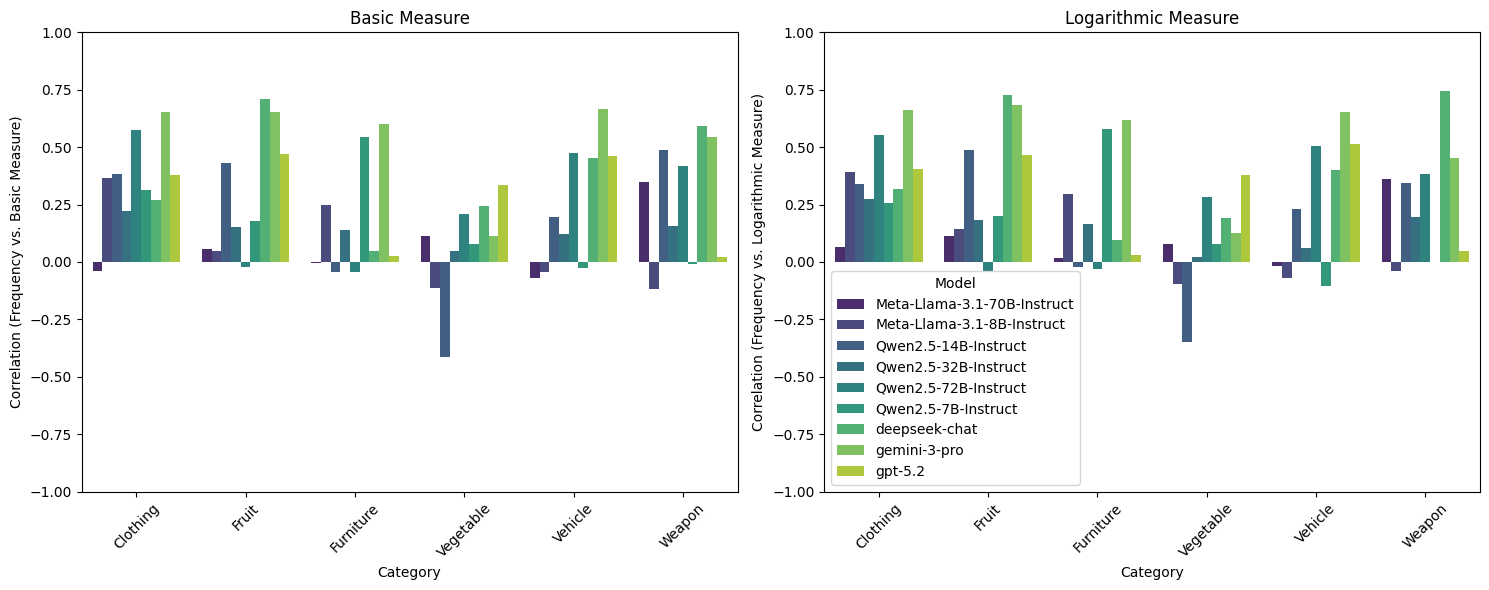

In [ ]:
# Family Resemblance Correlation Plots

unique_attributes_df['frequency'] = None  

for idx, row in unique_attributes_df.iterrows():
    model = row['model']
    category = row['category']
    item = row['item']
    
    freq = filtered_item_counts.loc[
        (filtered_item_counts['model'] == model) &
        (filtered_item_counts['category'] == category) &
        (filtered_item_counts['item'] == item), 
        'frequency'
    ]
    
    if not freq.empty:
        unique_attributes_df.at[idx, 'frequency'] = freq.values[0]

non_null_df = unique_attributes_df[unique_attributes_df['frequency'].notna()]

correlation_basic = (
    non_null_df.groupby(['category', 'model'])
    .apply(lambda x: x['basic_measure'].corr(x['frequency']))
    .reset_index(name='correlation')
)

correlation_log = (
    non_null_df.groupby(['category', 'model'])
    .apply(lambda x: x['log_measure'].corr(x['frequency']))
    .reset_index(name='correlation')
)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.barplot(data=correlation_basic, x='category', y='correlation', hue='model', palette="viridis", ax=axes[0], legend = False)
axes[0].set_title('Basic Measure')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Correlation (Frequency vs. Basic Measure)')
axes[0].tick_params(axis='x', rotation=45)  
axes[0].set_ylim(-1, 1)  

sns.barplot(data=correlation_log, x='category', y='correlation', hue='model', palette="viridis", ax=axes[1])
axes[1].set_title('Logarithmic Measure')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Correlation (Frequency vs. Logarithmic Measure)')
axes[1].tick_params(axis='x', rotation=45)  
axes[1].set_ylim(-1, 1) 
axes[1].legend(title='Model', loc='lower left')

plt.tight_layout()
plt.show()


In [12]:
#unique_attributes_df.loc[unique_attributes_df['model'] == 'deepseek-chat', 'model'] = 'DeepSeek'
#unique_attributes_df.loc[unique_attributes_df['model'] == 'gemini-3-pro', 'model'] = 'Gemini 3 Pro'
#unique_attributes_df.loc[unique_attributes_df['model'] == 'gpt-5.2', 'model'] = 'GPT-5.2'

C:\Users\AS\AppData\Local\Temp\ipykernel_20000\2254091472.py:44: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: corr_with_pval(x, 'basic_measure'))
C:\Users\AS\AppData\Local\Temp\ipykernel_20000\2254091472.py:50: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: corr_with_pval(x, 'log_measure'))
C:\Users\AS\AppData\Local\Temp\ipykernel_20000\2254091472.py:94: UserWarning: set_ti

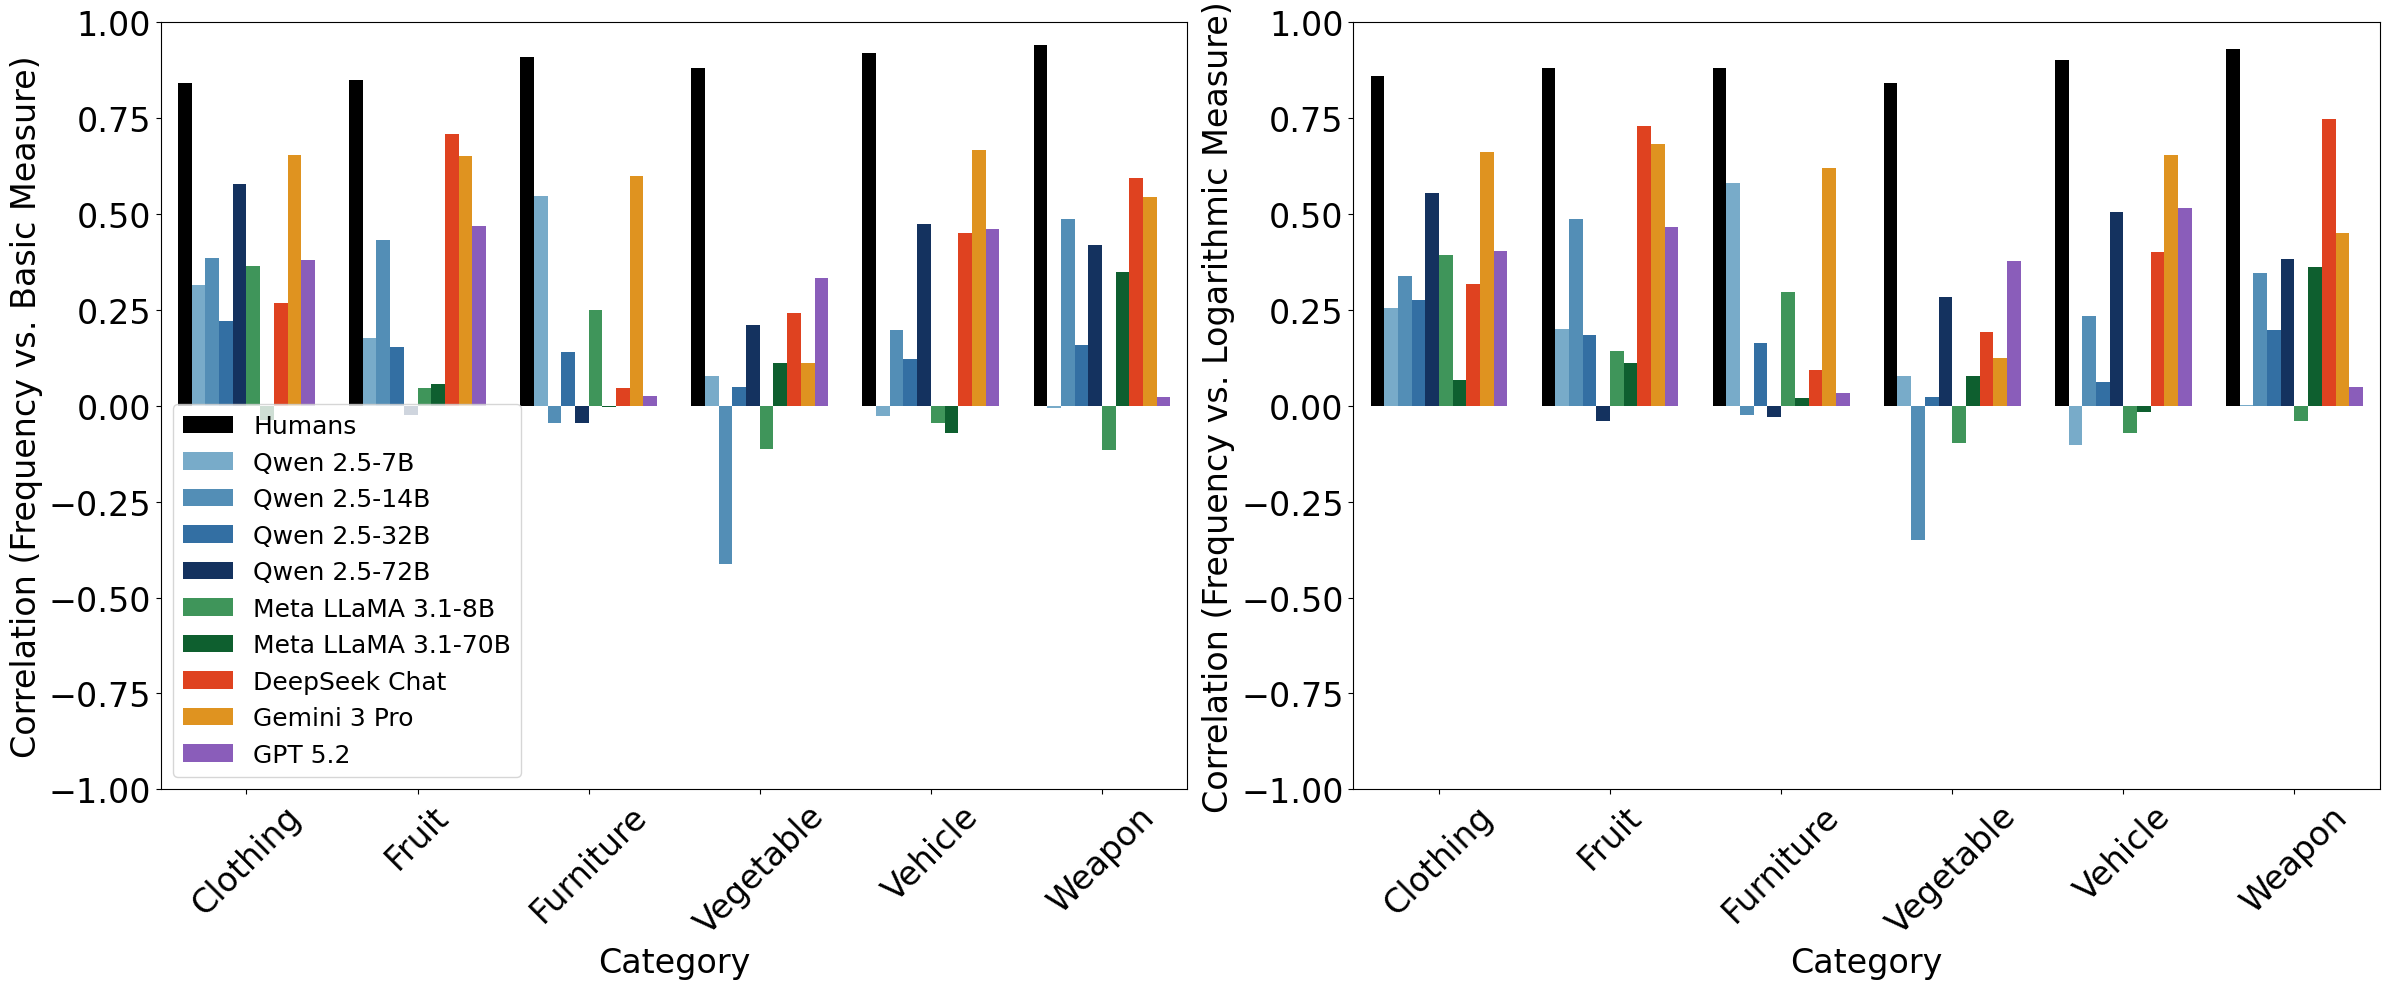

In [ ]:
fontsize = 24

model_palette = {
    'Qwen2.5-7B-Instruct': '#6baed6',
    'Qwen2.5-14B-Instruct': '#4292c6',
    'Qwen2.5-32B-Instruct': '#2171b5',
    'Qwen2.5-72B-Instruct': '#08306b',
    'Meta-Llama-3.1-8B-Instruct': '#31a354',
    'Meta-Llama-3.1-70B-Instruct': '#006d2c',
    'deepseek-chat': '#ff2e00',
    'gemini-3-pro': '#ff9900',
    'gpt-5.2': '#8a4dca',
    'Humans': 'black'
}

model_order = ['Humans'] + [model for model in model_palette.keys() if model != 'Humans']

non_null_df = unique_attributes_df.copy()
non_null_df['frequency'] = pd.to_numeric(non_null_df['frequency'], errors='coerce')
non_null_df['basic_measure'] = pd.to_numeric(non_null_df['basic_measure'], errors='coerce')
non_null_df['log_measure'] = pd.to_numeric(non_null_df['log_measure'], errors='coerce')

non_null_df = non_null_df.dropna(subset=['frequency', 'basic_measure', 'log_measure'])

def corr_with_pval(x, measure_col='basic_measure'):
    if len(x) < 2:
        return pd.Series({'correlation': float('nan'), 'p_value': float('nan')})
    r, p = pearsonr(x[measure_col], x['frequency'])
    return pd.Series({'correlation': r, 'p_value': p})

correlation_basic = (
    non_null_df.groupby(['category', 'model'])
    .apply(lambda x: corr_with_pval(x, 'basic_measure'))
    .reset_index()
)

correlation_log = (
    non_null_df.groupby(['category', 'model'])
    .apply(lambda x: corr_with_pval(x, 'log_measure'))
    .reset_index()
)

human_values_basic = [0.91, 0.92,0.88,0.94,0.85,0.84]
human_values_log = [0.88,0.90,0.84,0.93,0.88,0.86]

human_rows_basic = []
human_rows_log = []

for category, human_value_basic, human_value_log in zip(
    non_null_df['category'].unique(), 
    human_values_basic, 
    human_values_log
):
    human_rows_basic.append({'category': category, 'model': 'Humans', 
                             'correlation': human_value_basic, 'p_value': float('nan')})
    human_rows_log.append({'category': category, 'model': 'Humans', 
                           'correlation': human_value_log, 'p_value': float('nan')})

human_basic_df = pd.DataFrame(human_rows_basic)
human_log_df = pd.DataFrame(human_rows_log)

correlation_basic_combined = pd.concat([correlation_basic, human_basic_df], ignore_index=True)
correlation_log_combined = pd.concat([correlation_log, human_log_df], ignore_index=True)

correlation_basic_combined.sort_values(by='category', inplace=True)
correlation_log_combined.sort_values(by='category', inplace=True)

fig, axes = plt.subplots(1, 2, figsize=(24, 10))

sns.barplot(
    data=correlation_basic_combined, x='category', y='correlation', hue='model', 
    palette=model_palette, ax=axes[0], hue_order=model_order
)
axes[0].set_xlabel('Category', fontsize=fontsize)
axes[0].set_ylabel('Correlation (Frequency vs. Basic Measure)', fontsize=fontsize)
axes[0].tick_params(axis='x', rotation=45, labelsize=fontsize)
axes[0].tick_params(axis='y', labelsize=fontsize)
axes[0].set_xticklabels(axes[0].get_xticklabels(), fontsize=fontsize)
axes[0].set_ylim(-1, 1)

handles, _ = axes[0].get_legend_handles_labels()
new_labels = ['Humans', 'Qwen 2.5-7B', 'Qwen 2.5-14B', 'Qwen 2.5-32B', 'Qwen 2.5-72B', 
              'Meta LLaMA 3.1-8B', 'Meta LLaMA 3.1-70B', 'DeepSeek Chat', 'Gemini 3 Pro', 'GPT 5.2']
axes[0].legend(handles, new_labels, loc='lower left', fontsize=18)

sns.barplot(
    data=correlation_log_combined, x='category', y='correlation', hue='model', 
    palette=model_palette, ax=axes[1], hue_order=model_order, legend=False
)
axes[1].set_xlabel('Category', fontsize=fontsize)
axes[1].set_ylabel('Correlation (Frequency vs. Logarithmic Measure)', fontsize=fontsize)
axes[1].tick_params(axis='x', rotation=45, labelsize=fontsize)
axes[1].tick_params(axis='y', labelsize=fontsize)
axes[1].set_xticklabels(axes[1].get_xticklabels(), fontsize=fontsize)
axes[1].set_ylim(-1, 1)

plt.tight_layout()
plt.savefig('03_PropertiesFigures/figure_typicality_famres_correlations.pdf', format='pdf', bbox_inches='tight')
plt.show()

In [ ]:
non_null_df = unique_attributes_df.copy()

non_null_df['frequency'] = pd.to_numeric(non_null_df['frequency'], errors='coerce')
non_null_df['basic_measure'] = pd.to_numeric(non_null_df['basic_measure'], errors='coerce')
non_null_df['log_measure'] = pd.to_numeric(non_null_df['log_measure'], errors='coerce')

non_null_df = non_null_df.dropna(subset=['frequency', 'basic_measure', 'log_measure'])

def corr_with_pval(x, measure_col):
    if len(x) < 2:
        return pd.Series({'correlation': float('nan'), 'p_value': float('nan')})
    r, p = pearsonr(x[measure_col], x['frequency'])
    return pd.Series({'correlation': r, 'p_value': p})

correlation_basic = (
    non_null_df.groupby(['category', 'model'])
    .apply(lambda x: corr_with_pval(x, 'basic_measure'))
    .reset_index()
)

correlation_log = (
    non_null_df.groupby(['category', 'model'])
    .apply(lambda x: corr_with_pval(x, 'log_measure'))
    .reset_index()
)

human_values_basic = [0.91, 0.92, 0.88, 0.94, 0.85, 0.84]
human_values_log = [0.88, 0.90, 0.84, 0.93, 0.88, 0.86]

categories = non_null_df['category'].unique()

human_rows_basic = []
human_rows_log = []

for category, val_basic, val_log in zip(categories, human_values_basic, human_values_log):
    human_rows_basic.append({
        'category': category,
        'model': 'Humans',
        'correlation': val_basic,
        'p_value': float('nan')
    })
    human_rows_log.append({
        'category': category,
        'model': 'Humans',
        'correlation': val_log,
        'p_value': float('nan')
    })

human_basic_df = pd.DataFrame(human_rows_basic)
human_log_df = pd.DataFrame(human_rows_log)

correlation_basic_combined = pd.concat([correlation_basic, human_basic_df], ignore_index=True)
correlation_log_combined = pd.concat([correlation_log, human_log_df], ignore_index=True)

correlation_basic_combined.sort_values(by='category', inplace=True)
correlation_log_combined.sort_values(by='category', inplace=True)

print("Correlations and p-values for Basic Measure:")
for category in sorted(correlation_basic_combined['category'].unique()):
    cat_df = correlation_basic_combined[correlation_basic_combined['category'] == category]
    for _, row in cat_df.iterrows():
        corr_str = f"{row['correlation']:.4f}" if pd.notna(row['correlation']) else "NaN"
        pval_str = f"{row['p_value']:.4f}" if pd.notna(row['p_value']) else "NaN"

        sig = ''
        if pd.notna(row['p_value']):
            if row['p_value'] < 0.001:
                sig = '***'
            elif row['p_value'] < 0.01:
                sig = '**'
            elif row['p_value'] < 0.05:
                sig = '*'

        print(
            f"Category: {category}, "
            f"Model: {row['model']}, "
            f"Correlation: {corr_str}, "
            f"p-value: {pval_str} {sig}"
        )

print("\nCorrelations and p-values for Logarithmic Measure:")
for category in sorted(correlation_log_combined['category'].unique()):
    cat_df = correlation_log_combined[correlation_log_combined['category'] == category]
    for _, row in cat_df.iterrows():
        corr_str = f"{row['correlation']:.4f}" if pd.notna(row['correlation']) else "NaN"
        pval_str = f"{row['p_value']:.4f}" if pd.notna(row['p_value']) else "NaN"

        sig = ''
        if pd.notna(row['p_value']):
            if row['p_value'] < 0.001:
                sig = '***'
            elif row['p_value'] < 0.01:
                sig = '**'
            elif row['p_value'] < 0.05:
                sig = '*'

        print(
            f"Category: {category}, "
            f"Model: {row['model']}, "
            f"Correlation: {corr_str}, "
            f"p-value: {pval_str} {sig}"
        )

Correlations and p-values for Basic Measure:
Category: Clothing, Model: Meta-Llama-3.1-70B-Instruct, Correlation: -0.0379, p-value: 0.8892 
Category: Clothing, Model: gpt-5.2, Correlation: 0.3790, p-value: 0.1209 
Category: Clothing, Model: gemini-3-pro, Correlation: 0.6527, p-value: 0.0033 **
Category: Clothing, Model: deepseek-chat, Correlation: 0.2688, p-value: 0.2807 
Category: Clothing, Model: Qwen2.5-7B-Instruct, Correlation: 0.3140, p-value: 0.2197 
Category: Clothing, Model: Humans, Correlation: 0.8400, p-value: NaN 
Category: Clothing, Model: Qwen2.5-32B-Instruct, Correlation: 0.2207, p-value: 0.3946 
Category: Clothing, Model: Meta-Llama-3.1-8B-Instruct, Correlation: 0.3636, p-value: 0.1514 
Category: Clothing, Model: Qwen2.5-72B-Instruct, Correlation: 0.5768, p-value: 0.0153 *
Category: Clothing, Model: Qwen2.5-14B-Instruct, Correlation: 0.3851, p-value: 0.1269 
Category: Fruit, Model: Meta-Llama-3.1-70B-Instruct, Correlation: 0.0560, p-value: 0.8429 
Category: Fruit, Model:

C:\Users\AS\AppData\Local\Temp\ipykernel_20000\593859341.py:24: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: corr_with_pval(x, 'basic_measure'))
C:\Users\AS\AppData\Local\Temp\ipykernel_20000\593859341.py:30: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: corr_with_pval(x, 'log_measure'))


In [15]:
# Print p-values for basic_measure correlations
print("P-values for Basic Measure correlations:")
for category in correlation_basic_combined['category'].unique():
    cat_df = correlation_basic_combined[correlation_basic_combined['category'] == category]
    for _, row in cat_df.iterrows():
        print(f"Category: {category}, Model: {row['model']}, p-value: {row['p_value']:.4f}")

# Print p-values for log_measure correlations
print("\nP-values for Logarithmic Measure correlations:")
for category in correlation_log_combined['category'].unique():
    cat_df = correlation_log_combined[correlation_log_combined['category'] == category]
    for _, row in cat_df.iterrows():
        print(f"Category: {category}, Model: {row['model']}, p-value: {row['p_value']:.4f}")

P-values for Basic Measure correlations:
Category: Clothing, Model: Meta-Llama-3.1-70B-Instruct, p-value: 0.8892
Category: Clothing, Model: gpt-5.2, p-value: 0.1209
Category: Clothing, Model: gemini-3-pro, p-value: 0.0033
Category: Clothing, Model: deepseek-chat, p-value: 0.2807
Category: Clothing, Model: Qwen2.5-7B-Instruct, p-value: 0.2197
Category: Clothing, Model: Humans, p-value: nan
Category: Clothing, Model: Qwen2.5-32B-Instruct, p-value: 0.3946
Category: Clothing, Model: Meta-Llama-3.1-8B-Instruct, p-value: 0.1514
Category: Clothing, Model: Qwen2.5-72B-Instruct, p-value: 0.0153
Category: Clothing, Model: Qwen2.5-14B-Instruct, p-value: 0.1269
Category: Fruit, Model: Meta-Llama-3.1-70B-Instruct, p-value: 0.8429
Category: Fruit, Model: Meta-Llama-3.1-8B-Instruct, p-value: 0.8684
Category: Fruit, Model: Qwen2.5-14B-Instruct, p-value: 0.1074
Category: Fruit, Model: Qwen2.5-32B-Instruct, p-value: 0.5736
Category: Fruit, Model: Qwen2.5-72B-Instruct, p-value: 0.9323
Category: Fruit, Mo

C:\Users\AS\AppData\Local\Temp\ipykernel_20000\2466561716.py:49: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x['basic_measure'].corr(x['frequency']))
C:\Users\AS\AppData\Local\Temp\ipykernel_20000\2466561716.py:56: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x['log_measure'].corr(x['frequency']))
C:\Users\AS\AppData\Local\Temp\ipykernel_20000\2466561716.py:100: UserWarn

Furniture
Vehicle
Vegetable
Weapon
Fruit
Clothing


C:\Users\AS\AppData\Local\Temp\ipykernel_20000\2466561716.py:118: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(axes[1].get_xticklabels(), fontsize=fontsize)  # Set x-tick label size


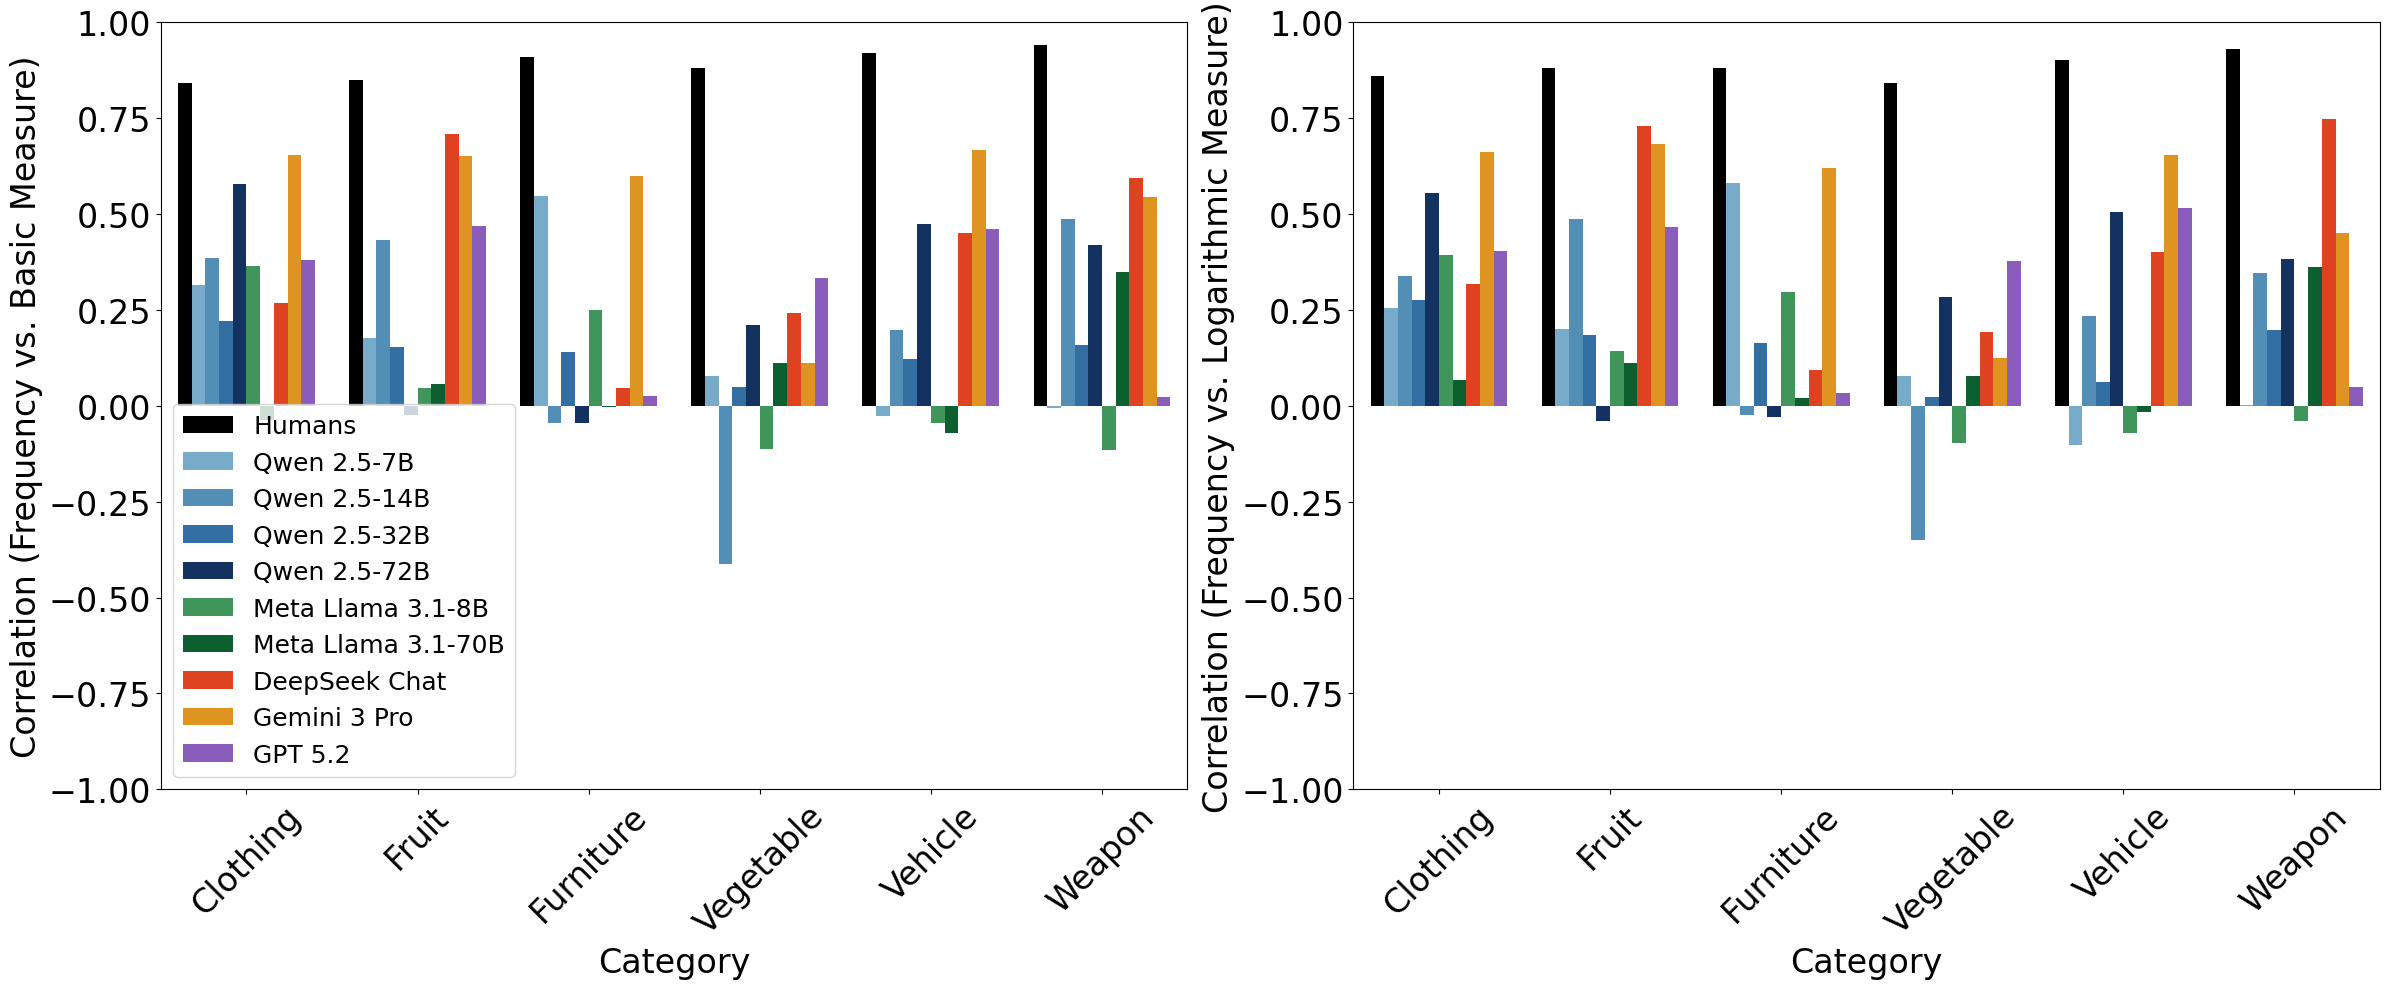

In [ ]:
fontsize = 24

model_palette = {
    'Qwen2.5-7B-Instruct': '#6baed6',
    'Qwen2.5-14B-Instruct': '#4292c6',
    'Qwen2.5-32B-Instruct': '#2171b5',
    'Qwen2.5-72B-Instruct': '#08306b',
    'Meta-Llama-3.1-8B-Instruct': '#31a354',
    'Meta-Llama-3.1-70B-Instruct': '#006d2c',
    'deepseek-chat': '#ff2e00',
    'gemini-3-pro': '#ff9900',
    'gpt-5.2': '#8a4dca',
    'Humans': 'black'  
}

model_order = ['Humans'] + [model for model in model_palette.keys() if model != 'Humans']

unique_attributes_df['frequency'] = None  

for idx, row in unique_attributes_df.iterrows():
    model = row['model']
    category = row['category']
    item = row['item']

    freq = filtered_item_counts.loc[
        (filtered_item_counts['model'] == model) &
        (filtered_item_counts['category'] == category) &
        (filtered_item_counts['item'] == item), 
        'frequency'
    ]
    
    if not freq.empty:
        unique_attributes_df.at[idx, 'frequency'] = freq.values[0]

non_null_df = unique_attributes_df[unique_attributes_df['frequency'].notna()]

correlation_basic = (
    non_null_df.groupby(['category', 'model'])
    .apply(lambda x: x['basic_measure'].corr(x['frequency']))
    .reset_index(name='correlation')
)

correlation_log = (
    non_null_df.groupby(['category', 'model'])
    .apply(lambda x: x['log_measure'].corr(x['frequency']))
    .reset_index(name='correlation')
)

human_values_basic = [0.91, 0.92,0.88,0.94,0.85,0.84]
human_values_log = [0.88,0.90,0.84,0.93,.88,0.86]

human_rows_basic = []
human_rows_log = []

for category, human_value_basic, human_value_log in zip(
    non_null_df['category'].unique(), 
    human_values_basic, 
    human_values_log
):
    print(category)
    human_rows_basic.append({'category': category, 'model': 'Humans', 'correlation': human_value_basic})
    human_rows_log.append({'category': category, 'model': 'Humans', 'correlation': human_value_log})

human_basic_df = pd.DataFrame(human_rows_basic)
human_log_df = pd.DataFrame(human_rows_log)

correlation_basic_combined = pd.concat([correlation_basic, human_basic_df], ignore_index=True)
correlation_log_combined = pd.concat([correlation_log, human_log_df], ignore_index=True)

correlation_basic_combined.sort_values(by='category', inplace=True)
correlation_log_combined.sort_values(by='category', inplace=True)

fig, axes = plt.subplots(1, 2, figsize=(24, 10))

sns.barplot(data=correlation_basic_combined, x='category', y='correlation', hue='model', 
            palette=model_palette, ax=axes[0], hue_order=model_order)

axes[0].set_xlabel('Category', fontsize = fontsize)
axes[0].set_ylabel('Correlation (Frequency vs. Basic Measure)', fontsize = fontsize)
axes[0].tick_params(axis='x', rotation=45, labelsize=fontsize) 
axes[0].tick_params(axis='y', labelsize=fontsize) 
axes[0].set_xticklabels(axes[0].get_xticklabels(), fontsize=fontsize) 
axes[0].set_ylim(-1, 1)  

handles, _ = axes[0].get_legend_handles_labels()
new_labels = ['Humans', 'Qwen 2.5-7B', 'Qwen 2.5-14B', 'Qwen 2.5-32B', 'Qwen 2.5-72B', 'Meta Llama 3.1-8B', 'Meta Llama 3.1-70B', 'DeepSeek Chat', 'Gemini 3 Pro', 'GPT 5.2']
axes[0].legend(handles, new_labels, loc='lower left', fontsize=18)

sns.barplot(data=correlation_log_combined, x='category', y='correlation', hue='model', 
            palette=model_palette, ax=axes[1], hue_order=model_order, legend=False)
axes[1].set_xlabel('Category', fontsize = fontsize)
axes[1].set_ylabel('Correlation (Frequency vs. Logarithmic Measure)', fontsize = fontsize)
axes[1].tick_params(axis='x', rotation=45, labelsize=fontsize) 
axes[1].tick_params(axis='y', labelsize=fontsize)  
axes[1].set_xticklabels(axes[1].get_xticklabels(), fontsize=fontsize)  
axes[1].set_ylim(-1, 1)  

plt.tight_layout()
plt.savefig('03_PropertiesFigures/figure_typicality_famres_correlations.pdf', format='pdf', bbox_inches='tight')
plt.show()


In [17]:
correlation_basic_combined['model'].unique()

array(['Meta-Llama-3.1-70B-Instruct', 'gpt-5.2', 'gemini-3-pro',
       'deepseek-chat', 'Qwen2.5-7B-Instruct', 'Humans',
       'Qwen2.5-32B-Instruct', 'Meta-Llama-3.1-8B-Instruct',
       'Qwen2.5-72B-Instruct', 'Qwen2.5-14B-Instruct'], dtype=object)

In [18]:
category

'Clothing'

In [ ]:
# Uniform Distribution of Unique Items per Category

unique_attributes_df  = pd.read_csv('famres_scores_df.csv', dtype=str, quoting=csv.QUOTE_ALL, encoding="utf-8")

def count_unique_attributes(row):
    category = row['category']
    model = row['model']
    current_attributes = set(row['attributes'])
    
    all_attributes = set(unique_attributes_df[(unique_attributes_df['category'] == category) & (unique_attributes_df['model'] == model)]['attributes'])
    
    unique_count = sum(1 for attr in current_attributes if attr not in all_attributes)
    return unique_count

unique_attributes_df['unique_attributes_count'] = unique_attributes_df.apply(count_unique_attributes, axis=1)

unique_attributes_df.head()

,model,category,item,attributes,attribute_scores,basic_measure,log_measure,frequency,unique_attributes_count
0,Qwen2.5-7B-Instruct,Furniture,armchair,"['spacious', 'reclining', 'upholstered', 'ergo...","[np.int64(4), np.int64(2), np.int64(4), np.int...",44,12.727719507927745,22,26
1,Qwen2.5-7B-Instruct,Furniture,bookshelf,"['spacious', 'sturdy', 'tall', 'organized', 'r...","[np.int64(4), np.int64(6), np.int64(2), np.int...",52,12.727719507927747,29,25
2,Qwen2.5-7B-Instruct,Furniture,bunk bed,"['multi-level', 'tiered', 'bed', 'supportive',...","[np.int64(3), np.int64(1), np.int64(1), np.int...",28,5.455321115357702,9,25
3,Qwen2.5-7B-Instruct,Furniture,cabinet,"['multi-compartment', 'fixed', 'rectangular', ...","[np.int64(1), np.int64(1), np.int64(9), np.int...",46,11.341425146807858,8,28
4,Qwen2.5-7B-Instruct,Furniture,chair,"['sturdy', 'four-legged', 'upholstered', 'ergo...","[np.int64(6), np.int64(1), np.int64(4), np.int...",54,15.079094765091224,30,27


C:\Users\AS\AppData\Local\Temp\ipykernel_20000\2634689558.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  tab10 = get_cmap('tab10').colors


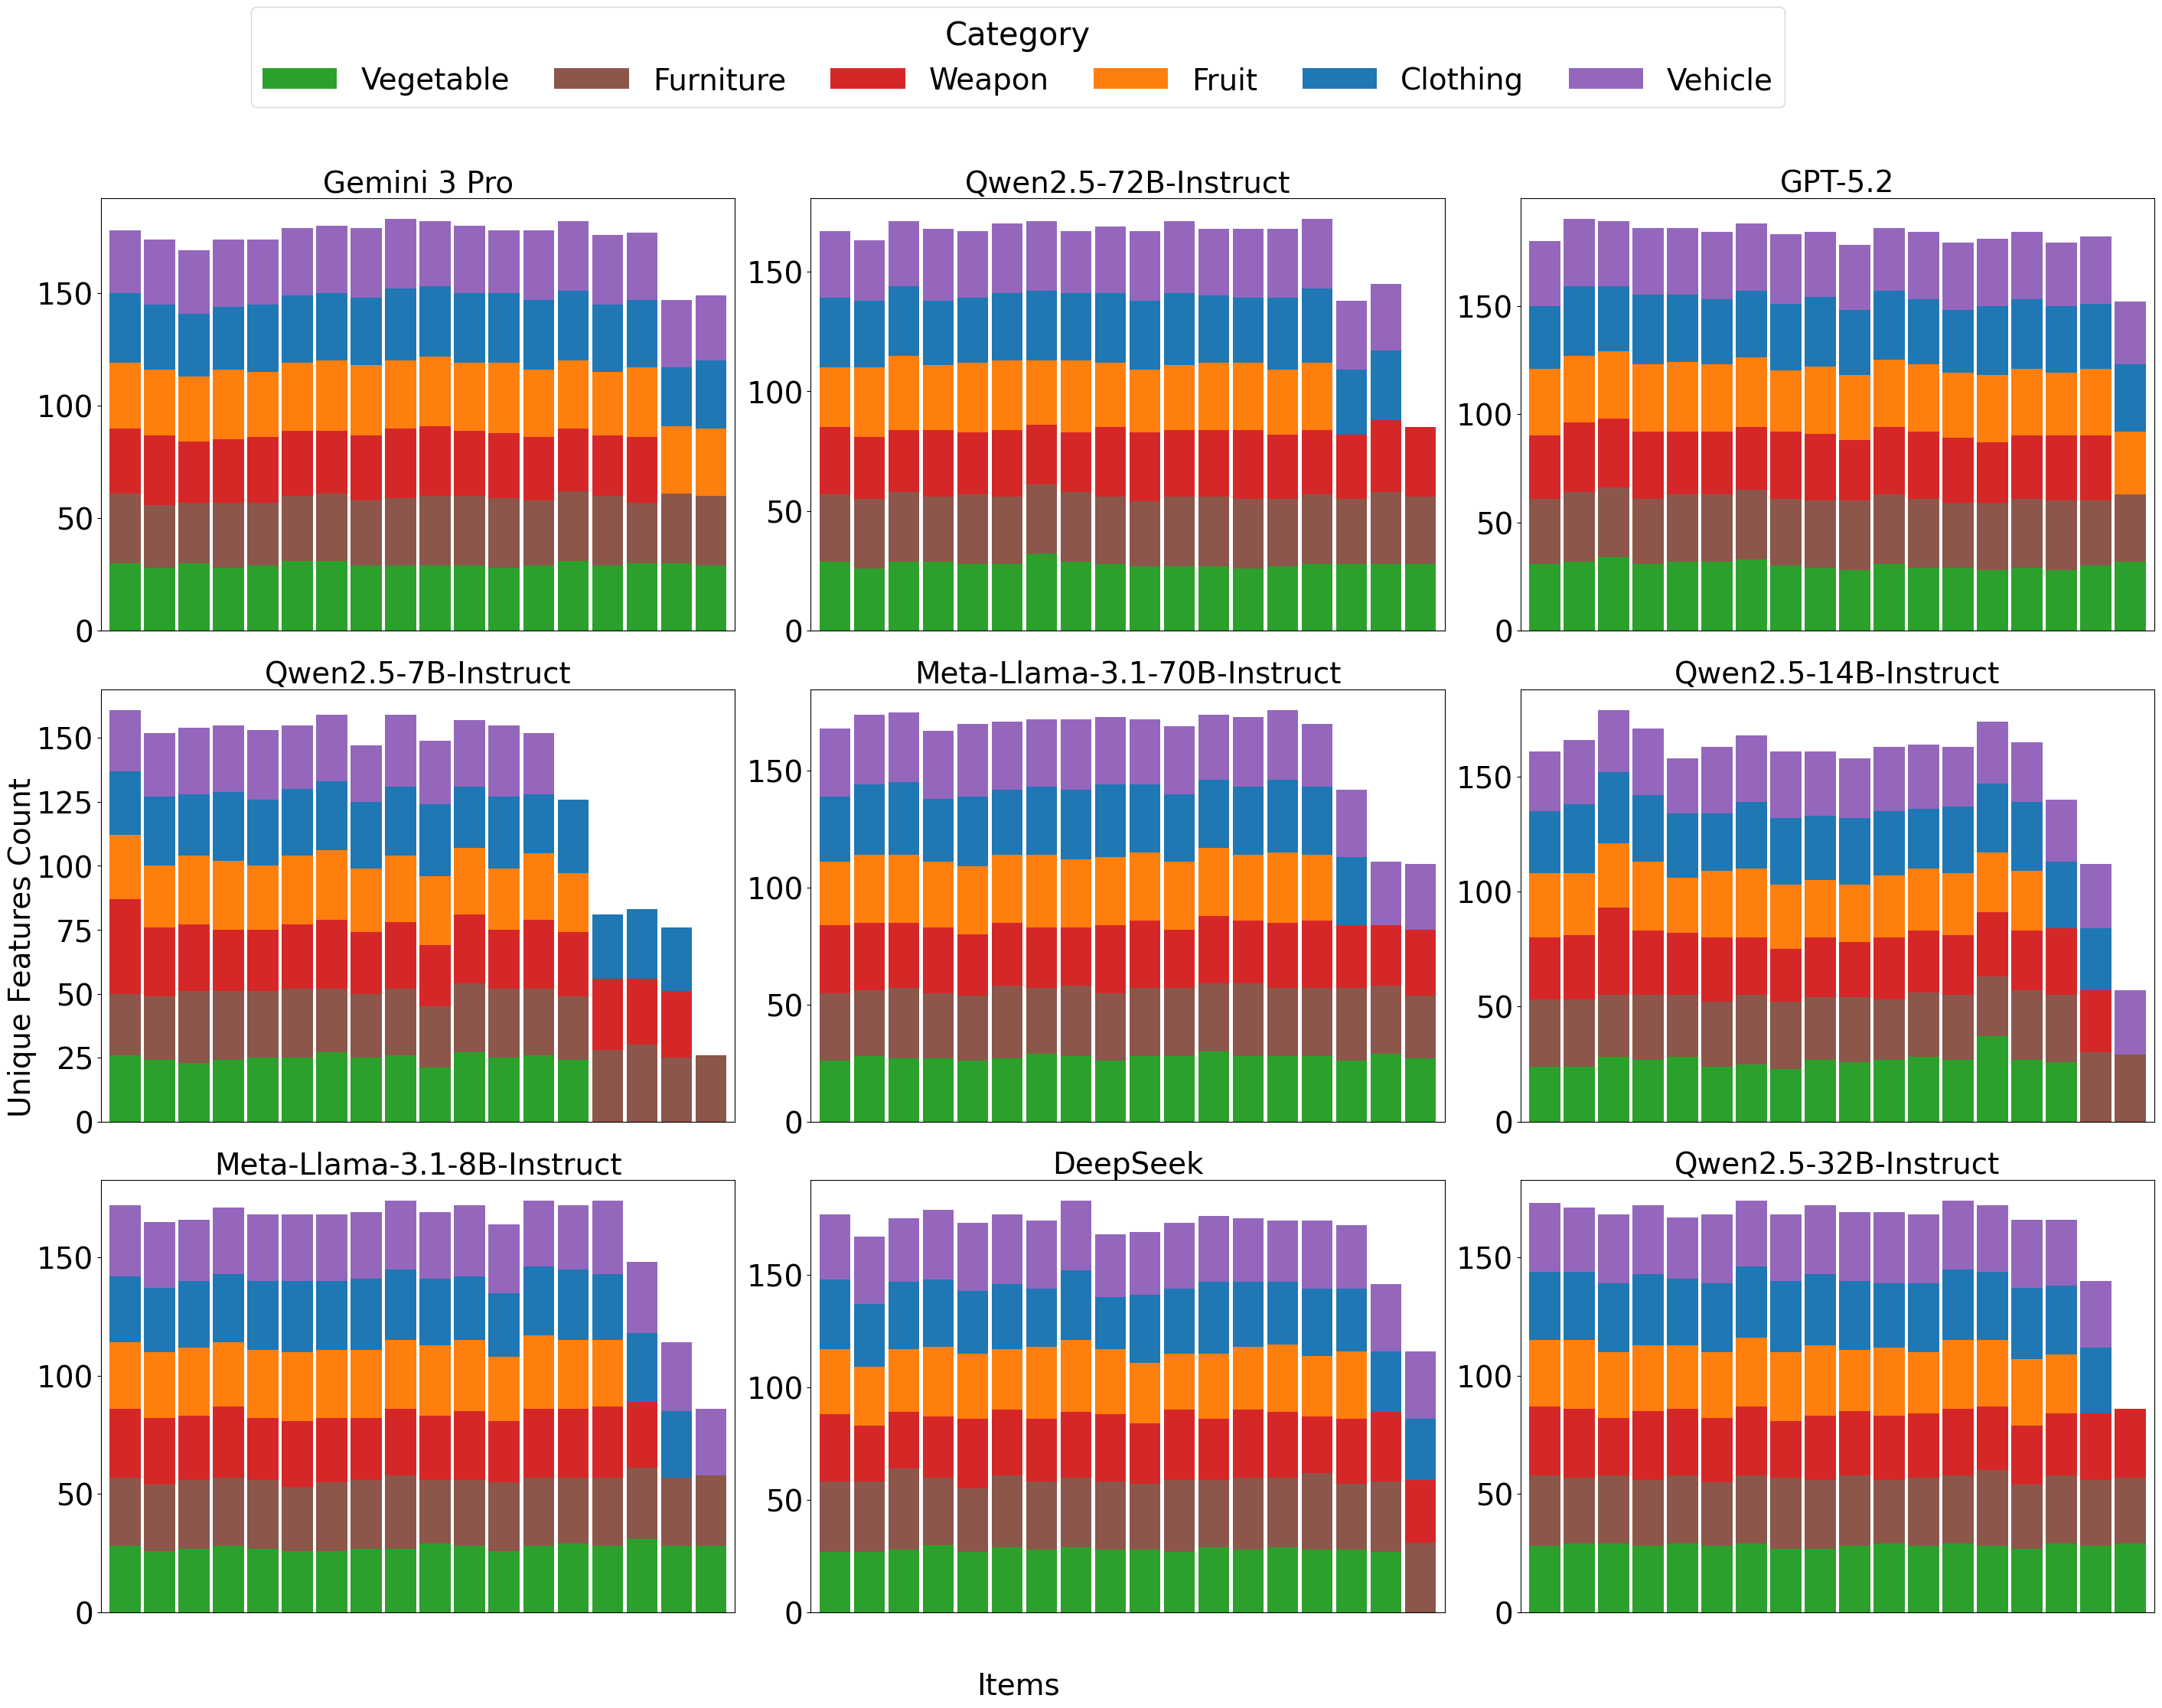

In [ ]:
unique_attributes_df = unique_attributes_df.sort_values(by='frequency', ascending=False)

tab10 = get_cmap('tab10').colors
category_color_map = {
    'Vegetable': tab10[2],
    'Furniture': tab10[5],
    'Weapon': tab10[3],
    'Fruit': tab10[1],
    'Clothing': tab10[0],
    'Vehicle': tab10[4],
}

model_name_map = {
    'gpt-5.2': 'GPT-5.2',
    'deepseek-chat': 'DeepSeek',
    'gemini-3-pro': 'Gemini 3 Pro'
}

unique_models = unique_attributes_df['model'].unique()

num_models = len(unique_models)
num_cols = 3
num_rows = (num_models // num_cols) + (num_models % num_cols > 0)

fig, axes = plt.subplots(
    nrows=num_rows,
    ncols=num_cols,
    figsize=(30, num_rows * 8)
)

axes = axes.flatten()

legend_handles = {}

for ax, model in zip(axes, unique_models):
    model_df = unique_attributes_df[unique_attributes_df['model'] == model]
    unique_categories = model_df['category'].unique()

    pivot_data = []

    for category in unique_categories:
        category_df = model_df[model_df['category'] == category].copy()
        category_df = category_df.sort_values(by='frequency', ascending=False)
        category_df['rank'] = range(1, len(category_df) + 1)
        pivot_data.append(category_df[['rank', 'category', 'unique_attributes_count']])

    if pivot_data:
        pivot_df = pd.concat(pivot_data)

        pivot_table = pivot_df.pivot_table(
            index='rank',
            columns='category',
            values='unique_attributes_count',
            fill_value=0
        )

        pivot_table = pivot_table.reindex(columns=category_color_map.keys(), fill_value=0)

        pivot_table.plot(
            kind='bar',
            stacked=True,
            ax=ax,
            width=0.9,
            color=[category_color_map[c] for c in pivot_table.columns]
        )

        if not legend_handles:
            handles, labels = ax.get_legend_handles_labels()
            for h, l in zip(handles, labels):
                legend_handles[l] = h

    display_name = model_name_map.get(model, model)

    ax.set_title(display_name, fontsize=28)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(axis='both', labelsize=28)
    ax.set_xticks([])

    legend = ax.get_legend()
    if legend is not None:
        legend.remove()

for i in range(len(unique_models), len(axes)):
    axes[i].axis('off')

fig.supxlabel('Items', fontsize=28, y=0.09)
fig.supylabel('Unique Features Count', fontsize=28, x=0.06)

fig.legend(
    legend_handles.values(),
    legend_handles.keys(),
    loc='upper center',
    ncol=len(category_color_map),
    fontsize=28,
    title='Category',
    title_fontsize=30,
    handlelength=2.5,
    columnspacing=1.5,
    bbox_to_anchor=(0.5, 1.02)
)

plt.tight_layout(rect=[0.05, 0.1, 1, 0.93])

plt.savefig(
    '03_PropertiesFigures/appendix_figure_typicality_uniquefeat_distributions.pdf',
    format='pdf',
    bbox_inches='tight'
)

plt.show()

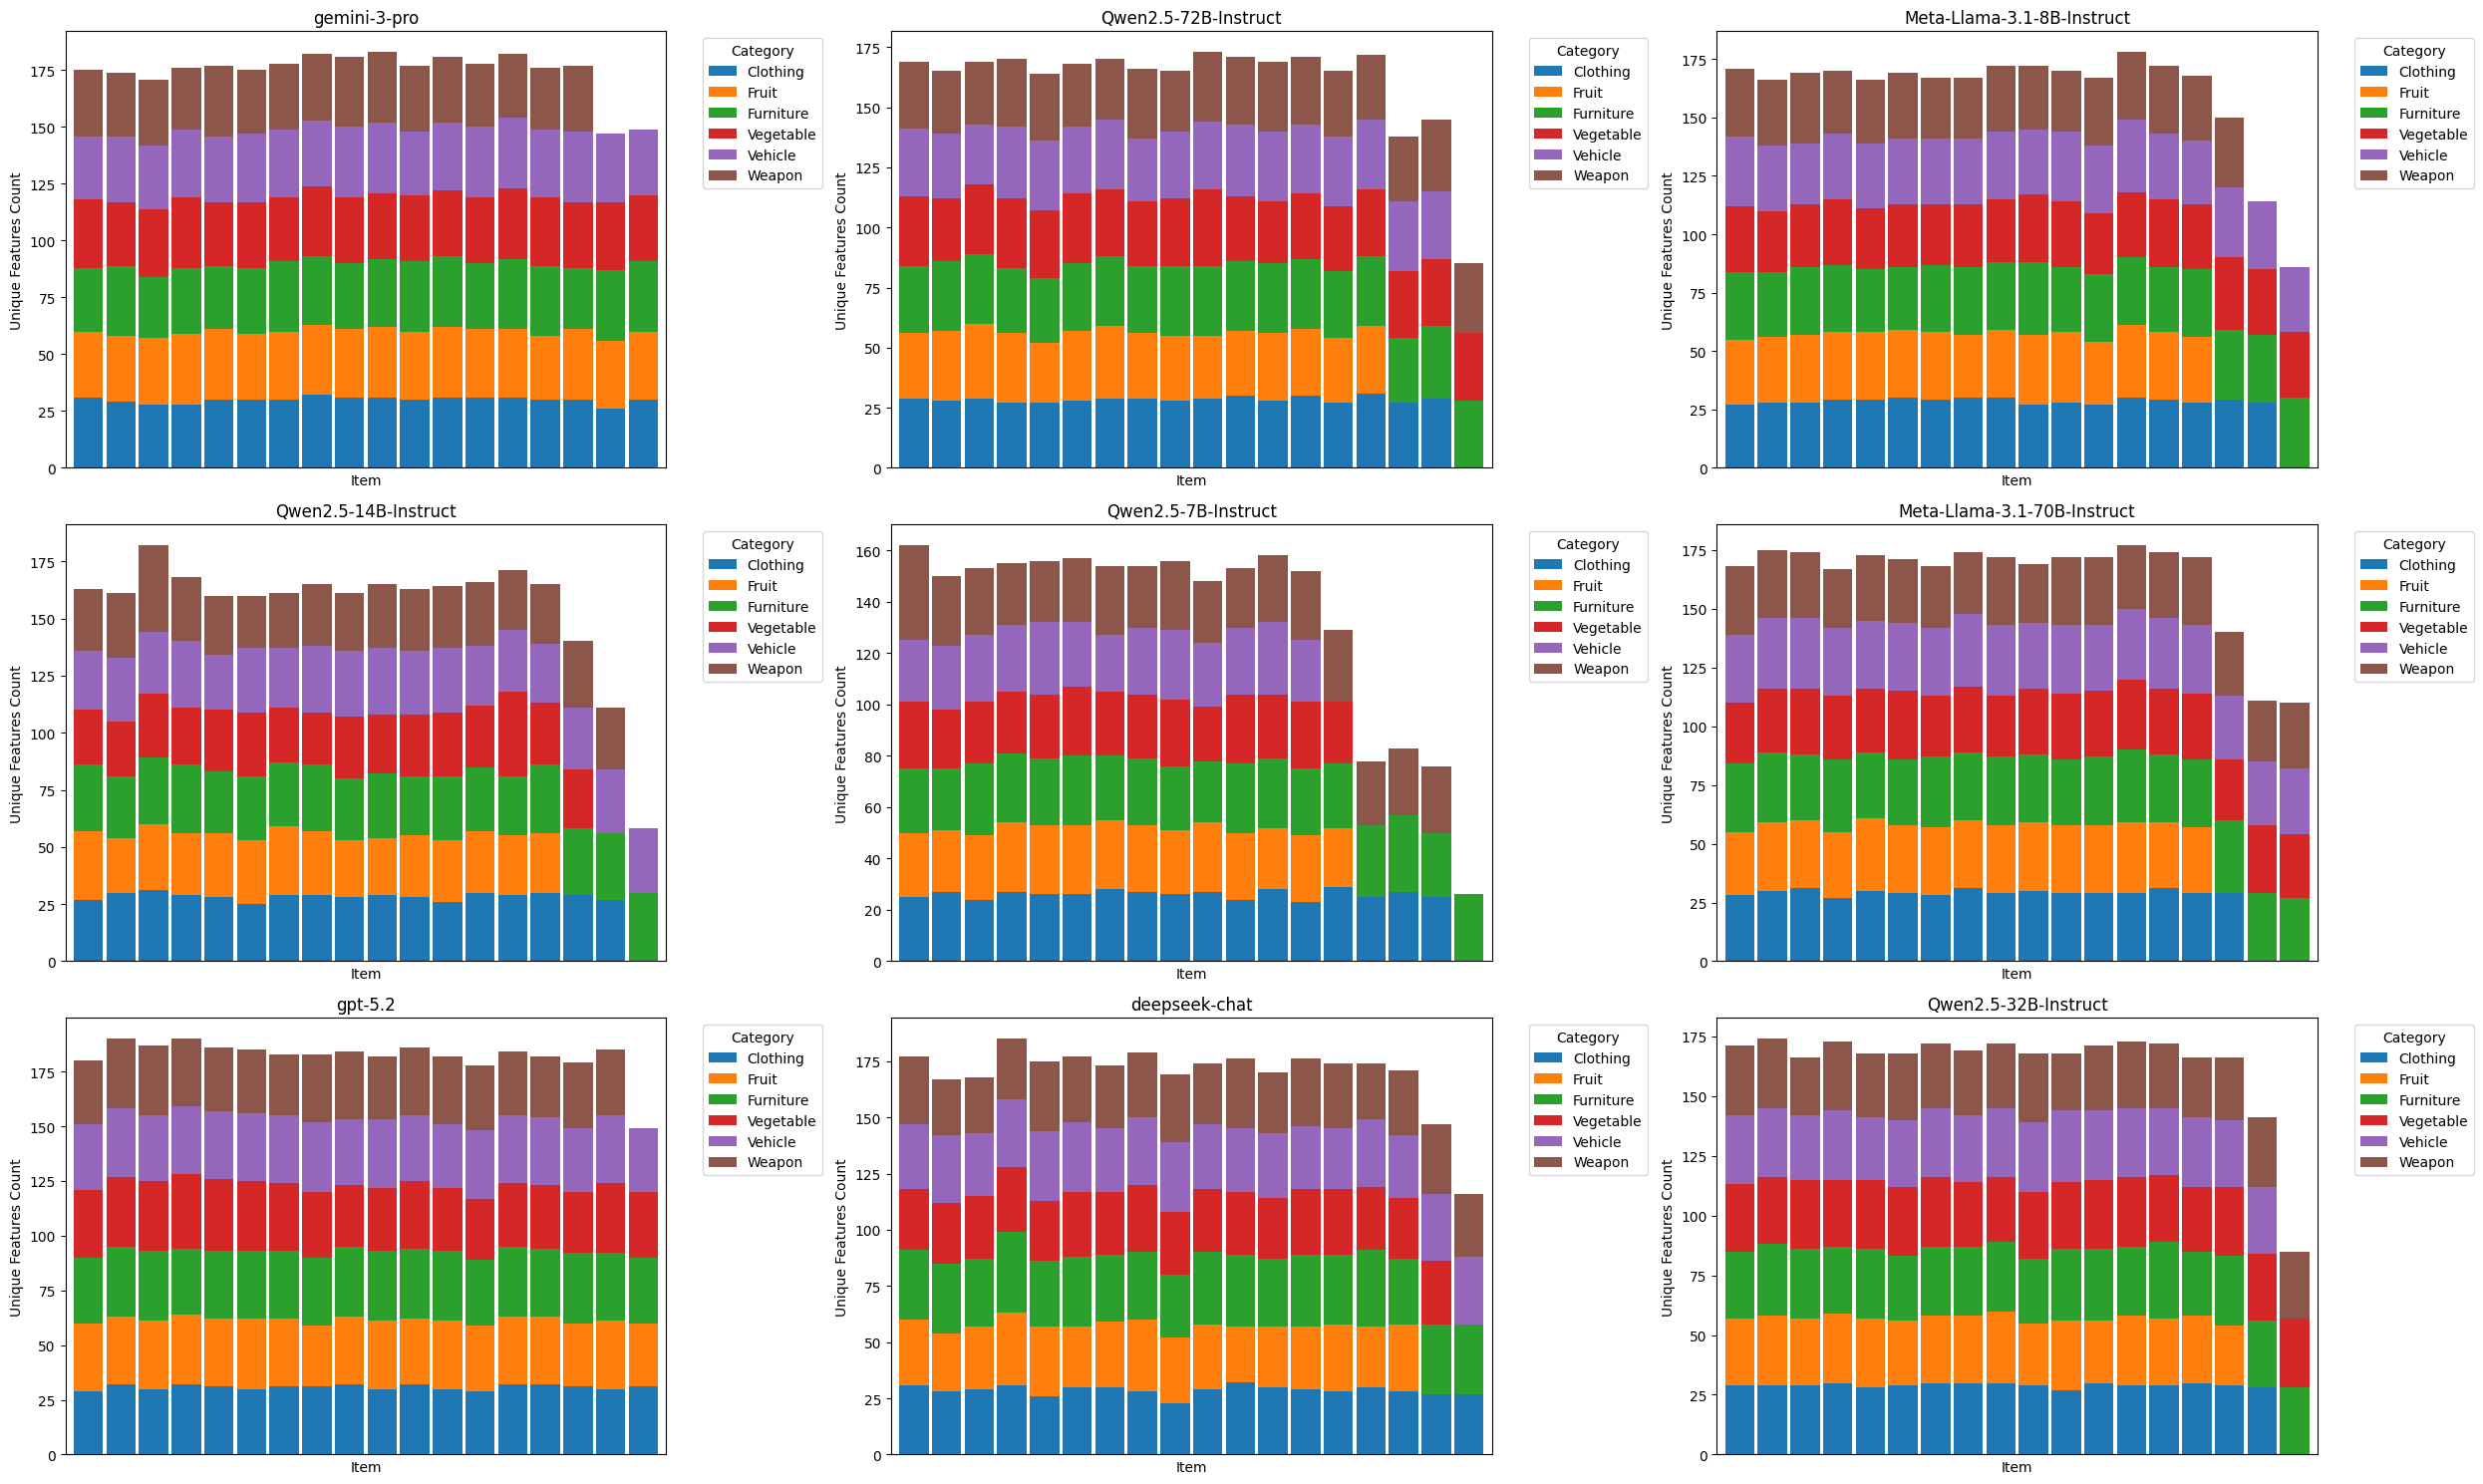

In [ ]:
unique_attributes_df = unique_attributes_df.sort_values(by='frequency', ascending=False)

unique_models = unique_attributes_df['model'].unique()

num_models = len(unique_models)
num_cols = 3
num_rows = (num_models // num_cols) + (num_models % num_cols > 0)  
fig, axes = plt.subplots(nrows=num_rows, ncols=num_cols, figsize=(25, num_rows * 5), tight_layout=True)

axes = axes.flatten()

for ax, model in zip(axes, unique_models):
    
    model_df = unique_attributes_df[unique_attributes_df['model'] == model]
    unique_categories = model_df['category'].unique()

    pivot_data = []

    for category in unique_categories:
        category_df = model_df[model_df['category'] == category]

        category_df = category_df.sort_values(by='frequency', ascending=False)
        category_df['rank'] = range(1, len(category_df) + 1)  

        pivot_data.append(category_df[['rank', 'category', 'unique_attributes_count']])

    pivot_df = pd.concat(pivot_data)

    pivot_table = pivot_df.pivot_table(index='rank', 
                                        columns='category', 
                                        values='unique_attributes_count',
                                        fill_value=0)

    pivot_table.plot(kind='bar', stacked=True, ax=ax, width=0.9)

    ax.set_title(f'{model}')
    ax.set_xlabel('Item')
    ax.set_ylabel('Unique Features Count')
    ax.set_xticks([])  
    ax.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')

for i in range(len(unique_models), len(axes)):
    axes[i].axis('off')  

plt.tight_layout()
plt.show()

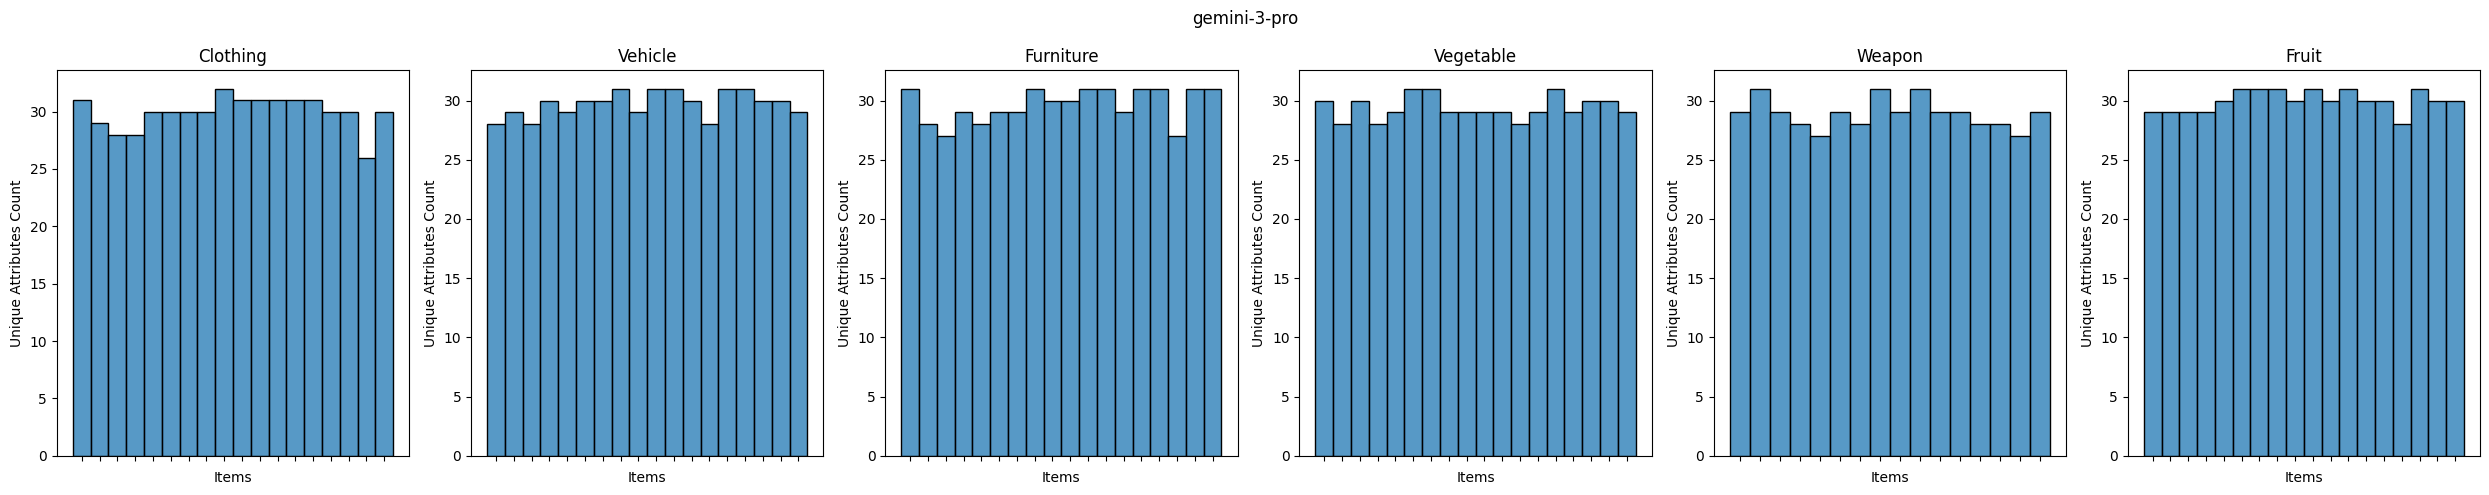

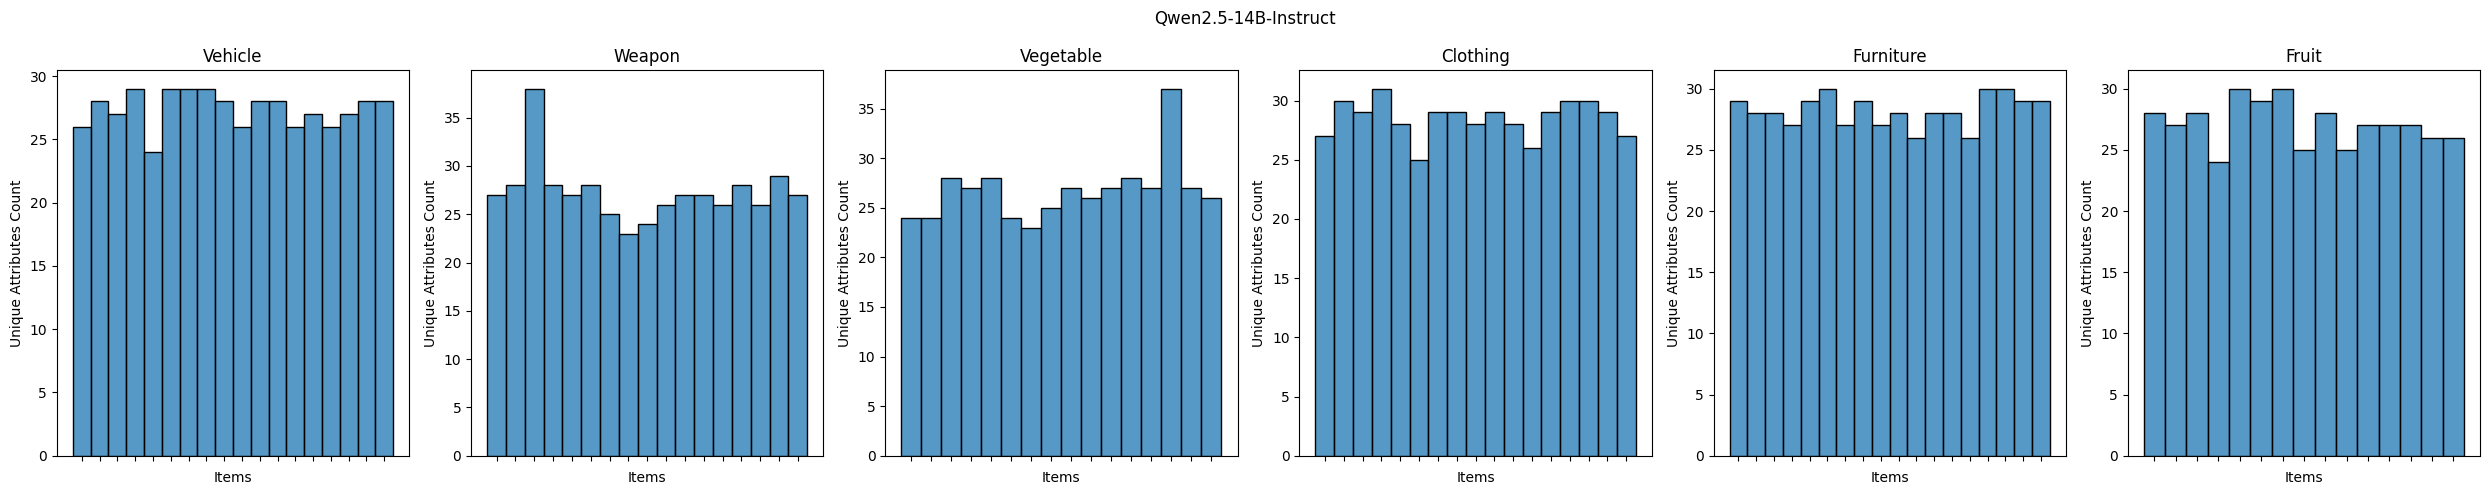

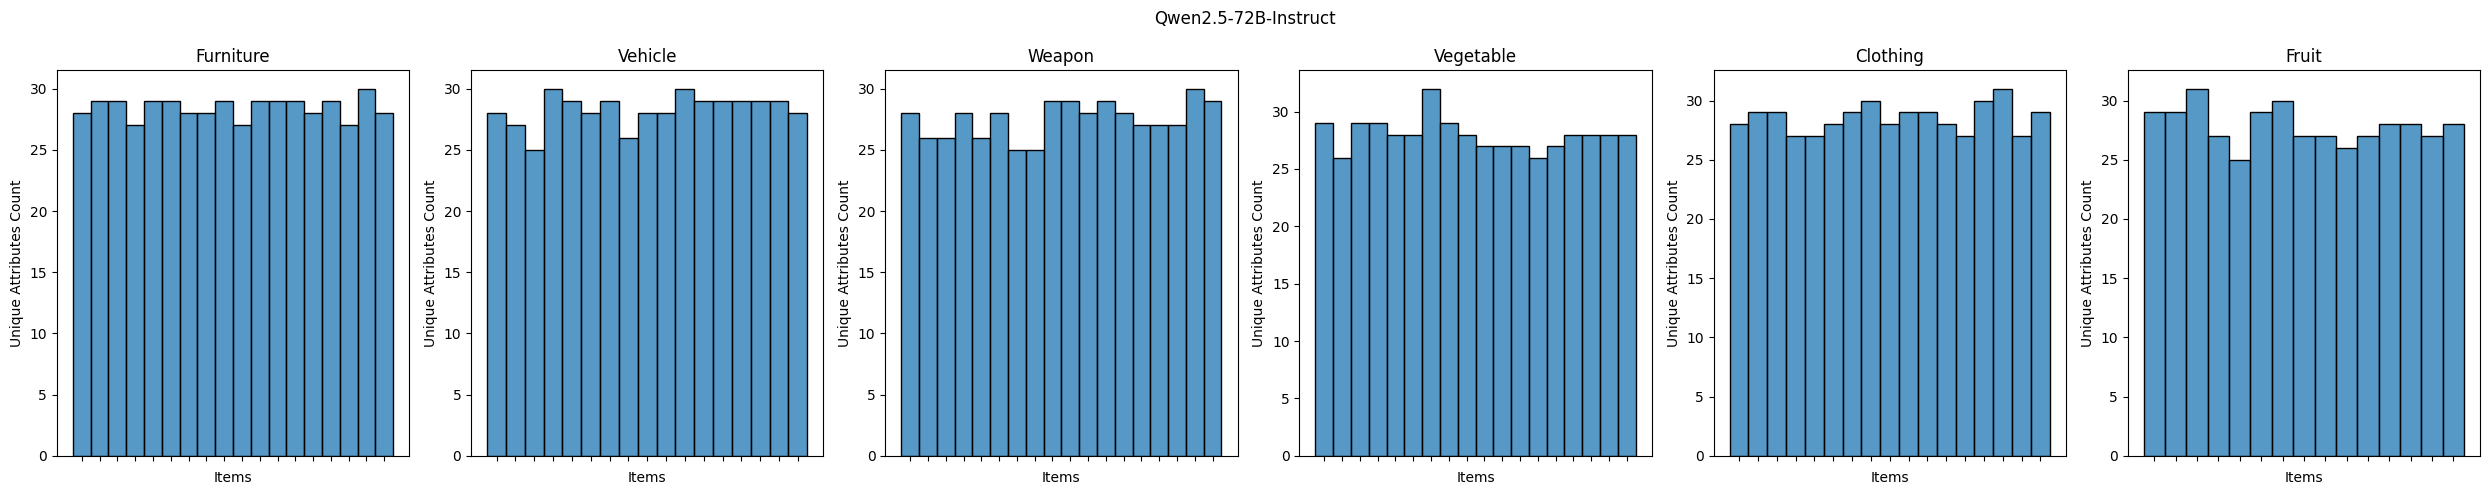

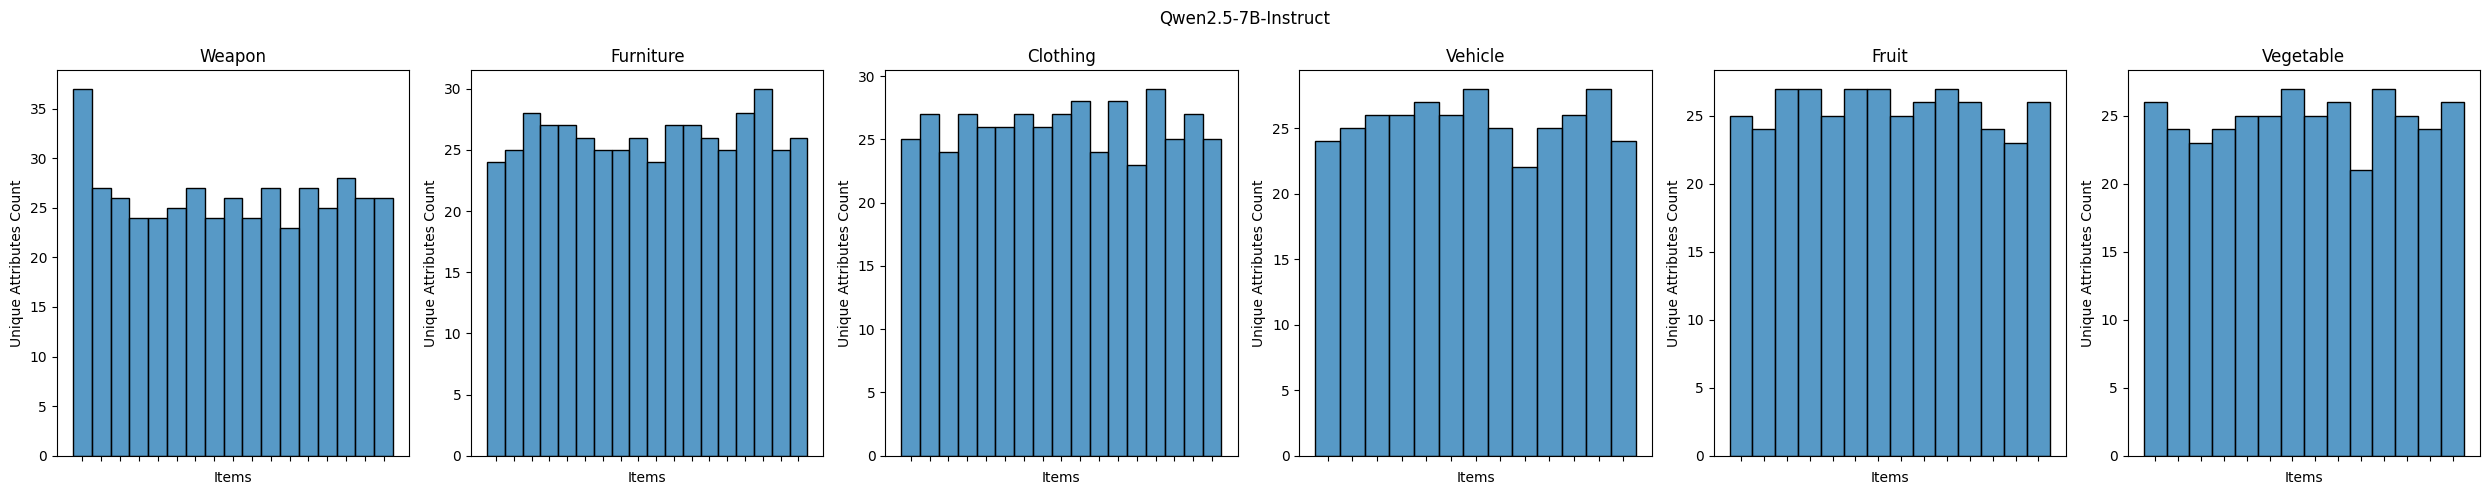

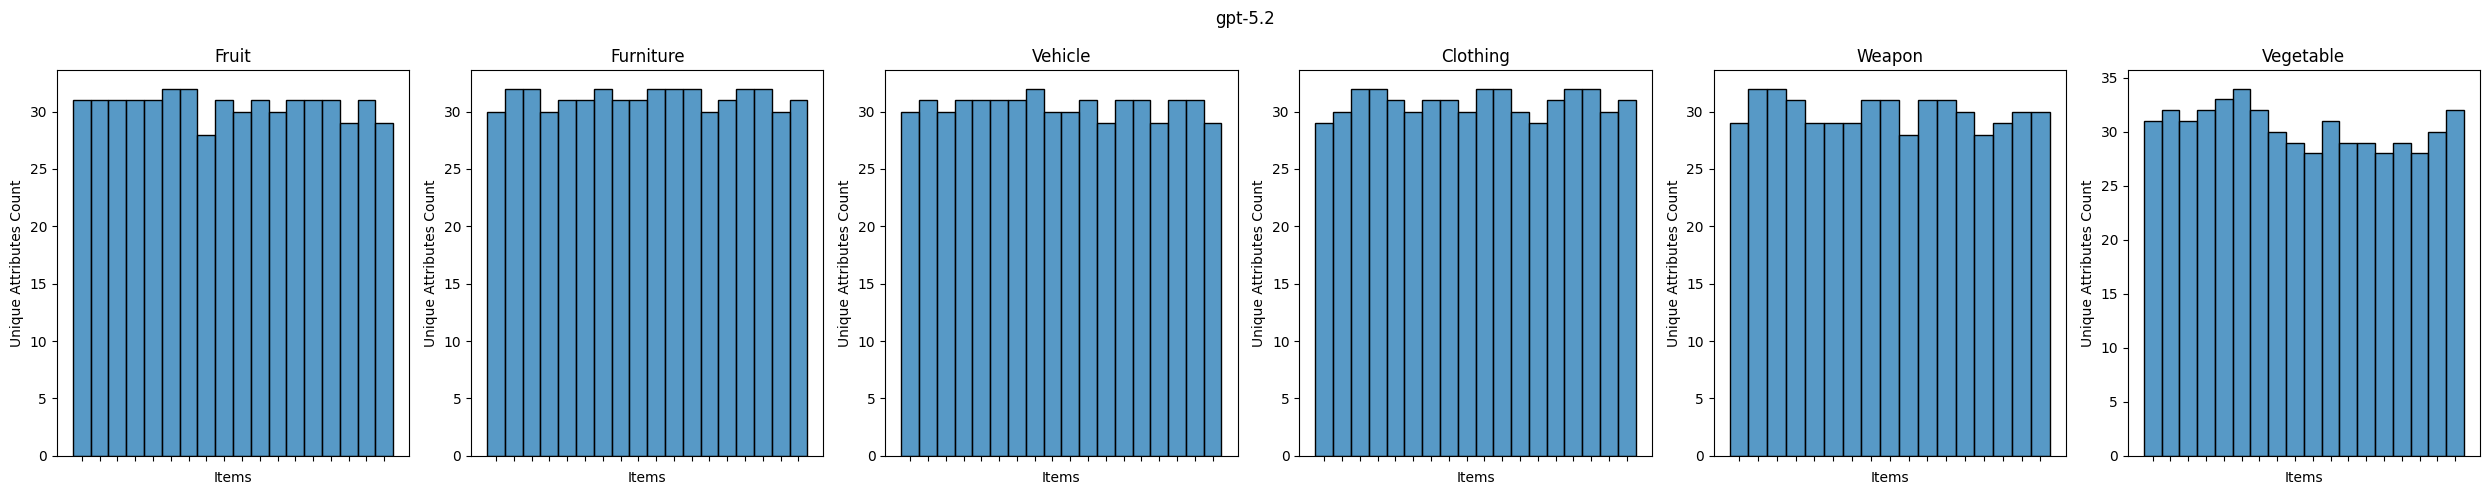

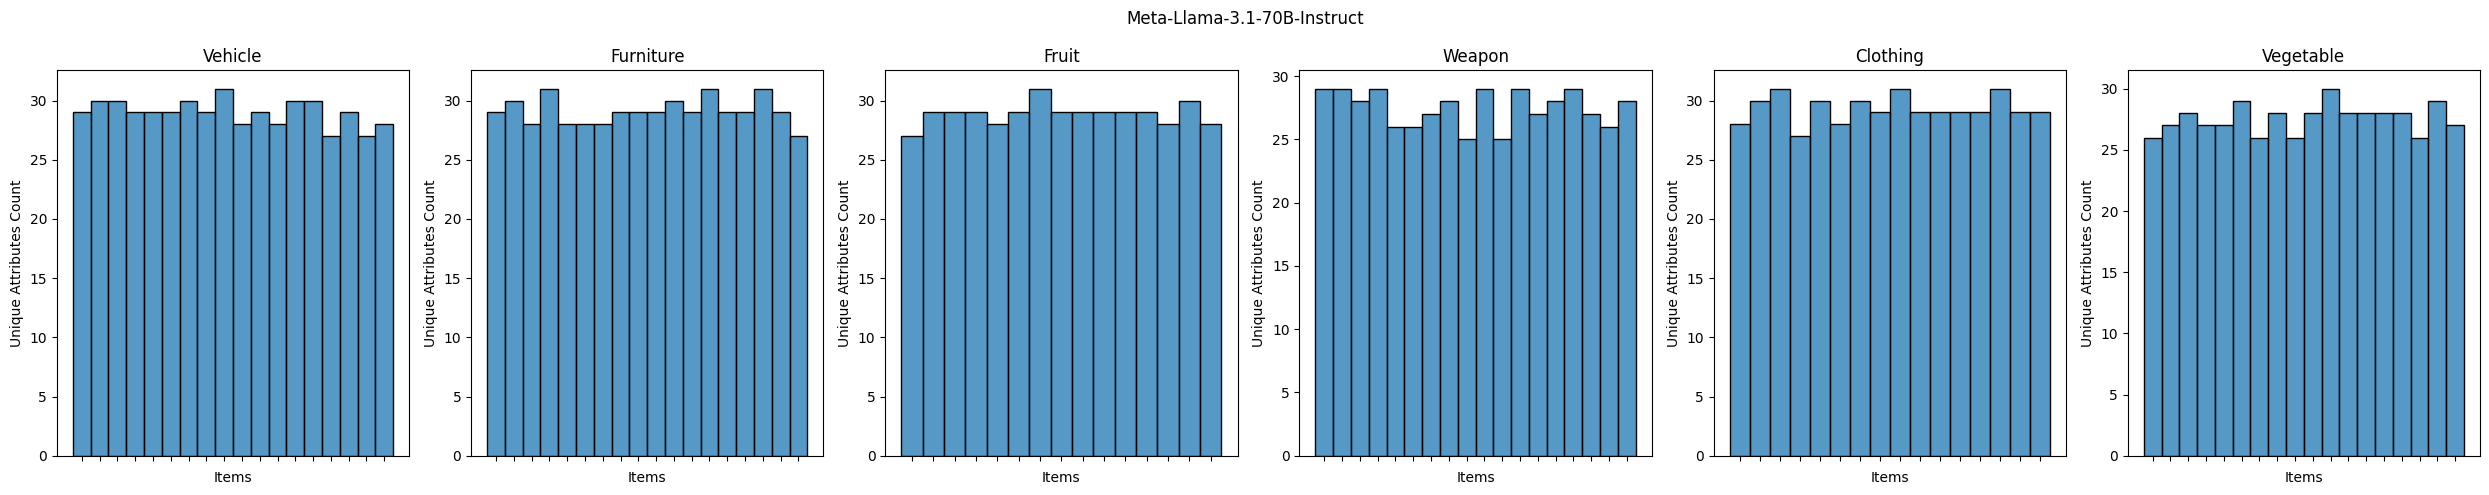

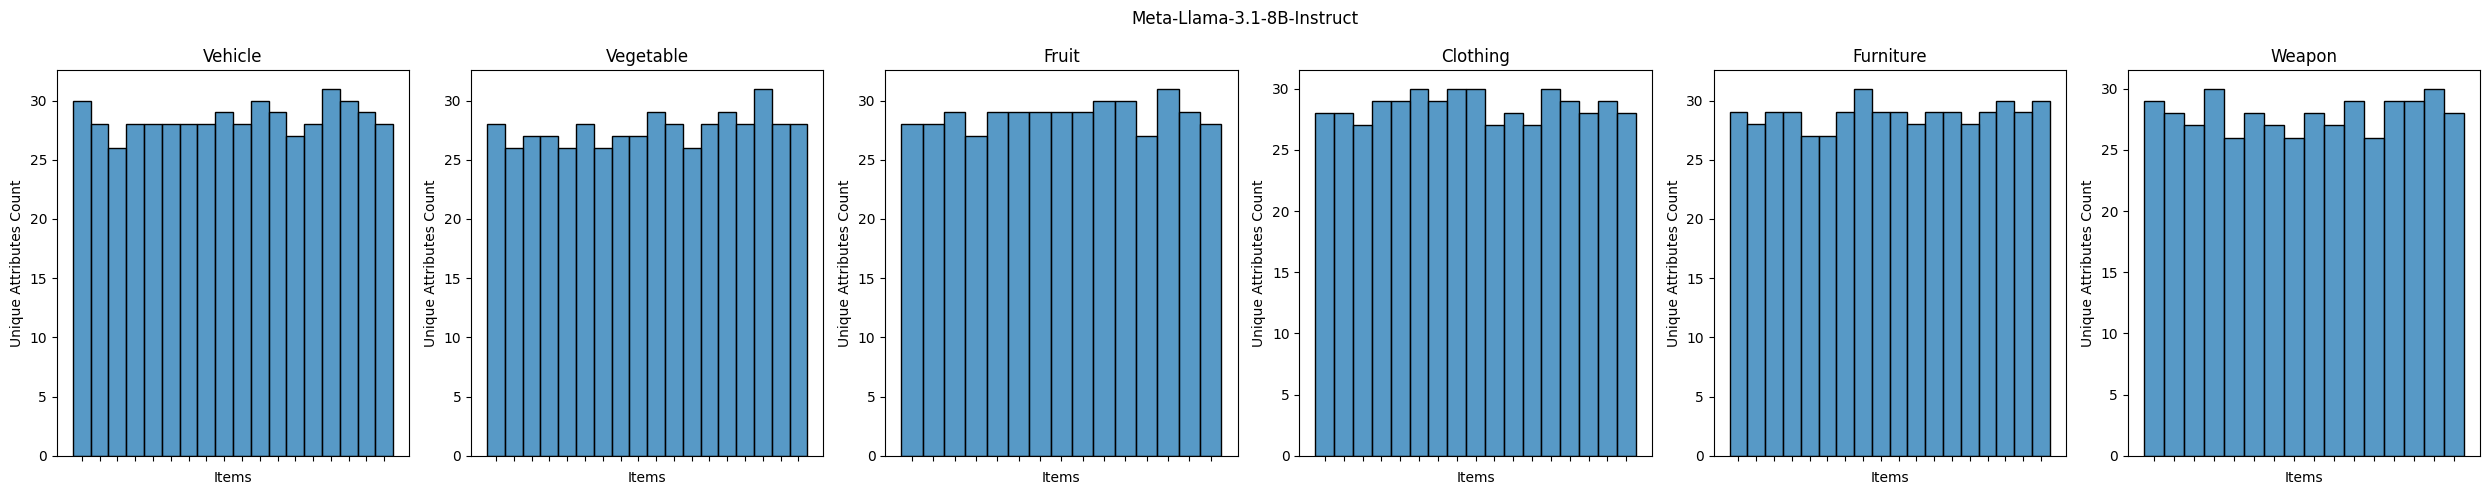

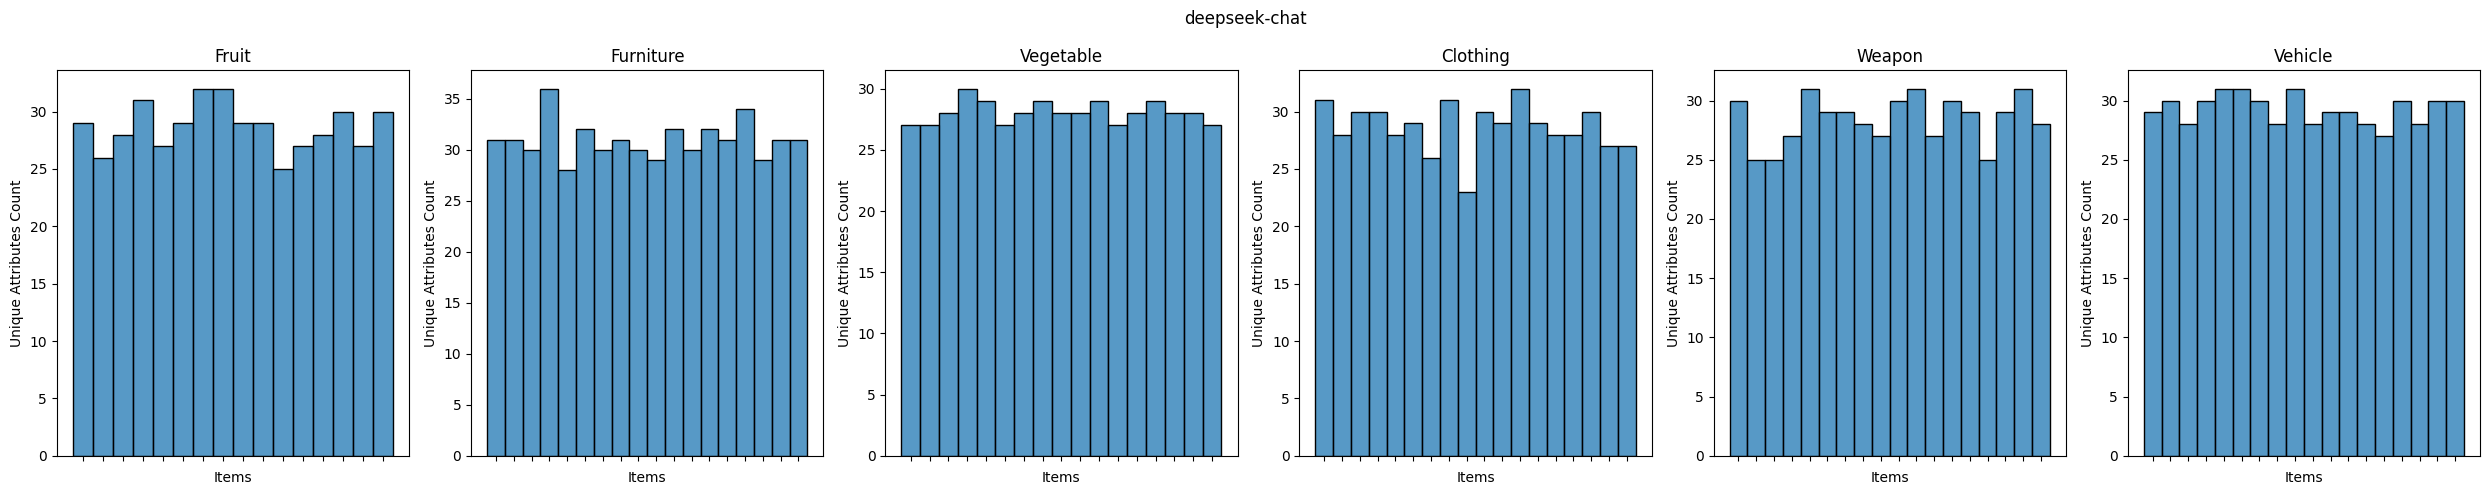

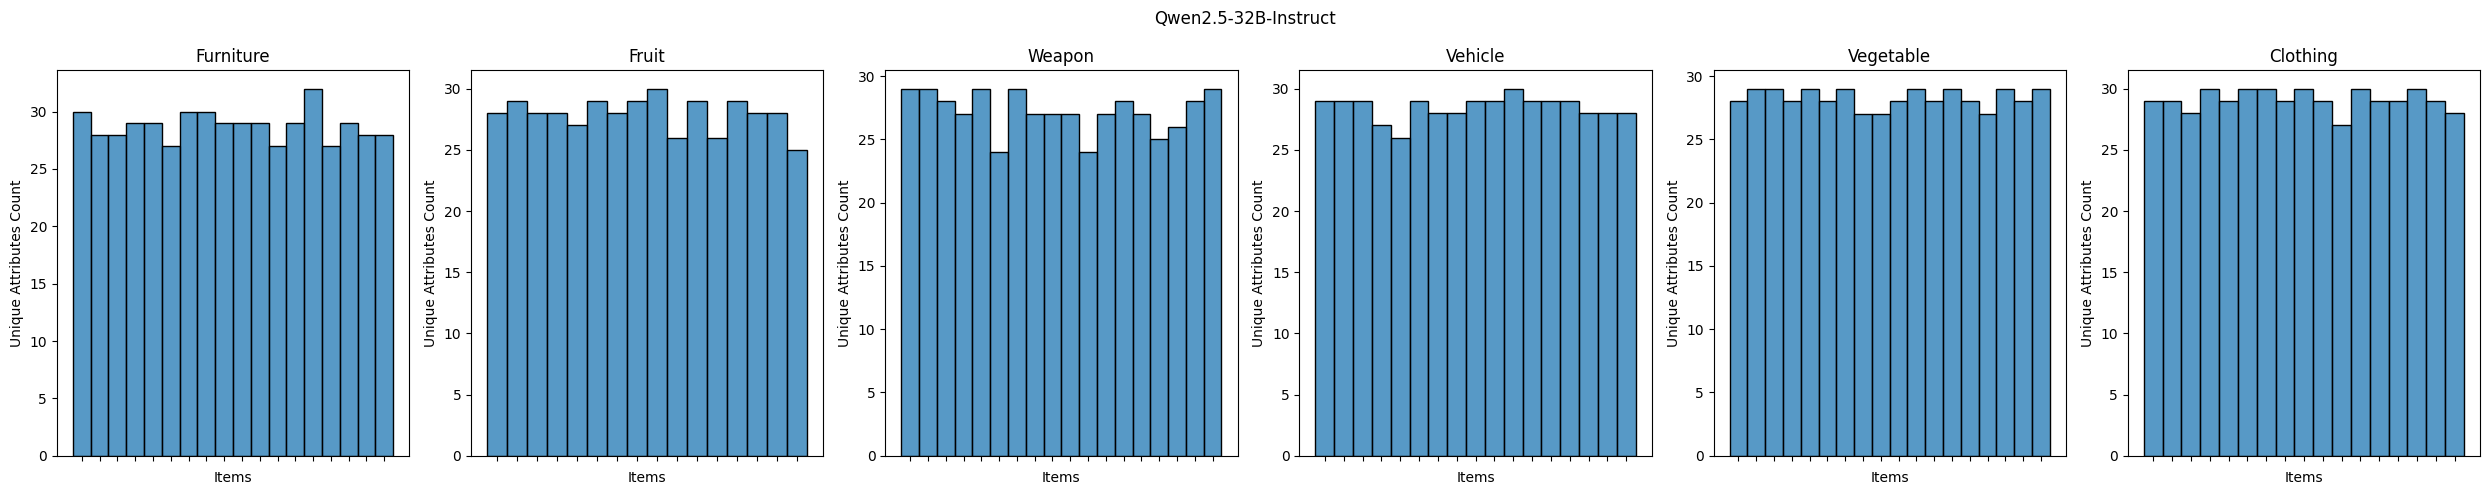

In [ ]:
# Plot Unique Attributes Distribution for one example category

unique_attributes_df = unique_attributes_df.sort_values(by='frequency', ascending=False)

unique_models = unique_attributes_df['model'].unique()

for model in unique_models:
    
    model_df = unique_attributes_df[unique_attributes_df['model'] == model]
    unique_categories = model_df['category'].unique()

    
    num_categories = len(unique_categories)
    fig, axes = plt.subplots(nrows=1, ncols=num_categories, figsize=(25, 5), tight_layout=True)
    
    for ax, category in zip(axes, unique_categories):
        category_df = model_df[model_df['category'] == category]
        
        category_df = category_df.sort_values(by='frequency', ascending=False)

        sns.histplot(data=category_df, x='item', weights='unique_attributes_count',
                     ax=ax, discrete=True, kde=False)
        
        ax.set_title(category)
        ax.set_xlabel('Items')
        ax.set_ylabel('Unique Attributes Count')
        ax.set_xticklabels([])  

        item_labels = category_df['item'].tolist() 

    plt.suptitle(f'{model}')
    plt.show()


C:\Users\AS\AppData\Local\Temp\ipykernel_20000\4250785571.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x['unique_attributes_count'].corr(x['frequency']))


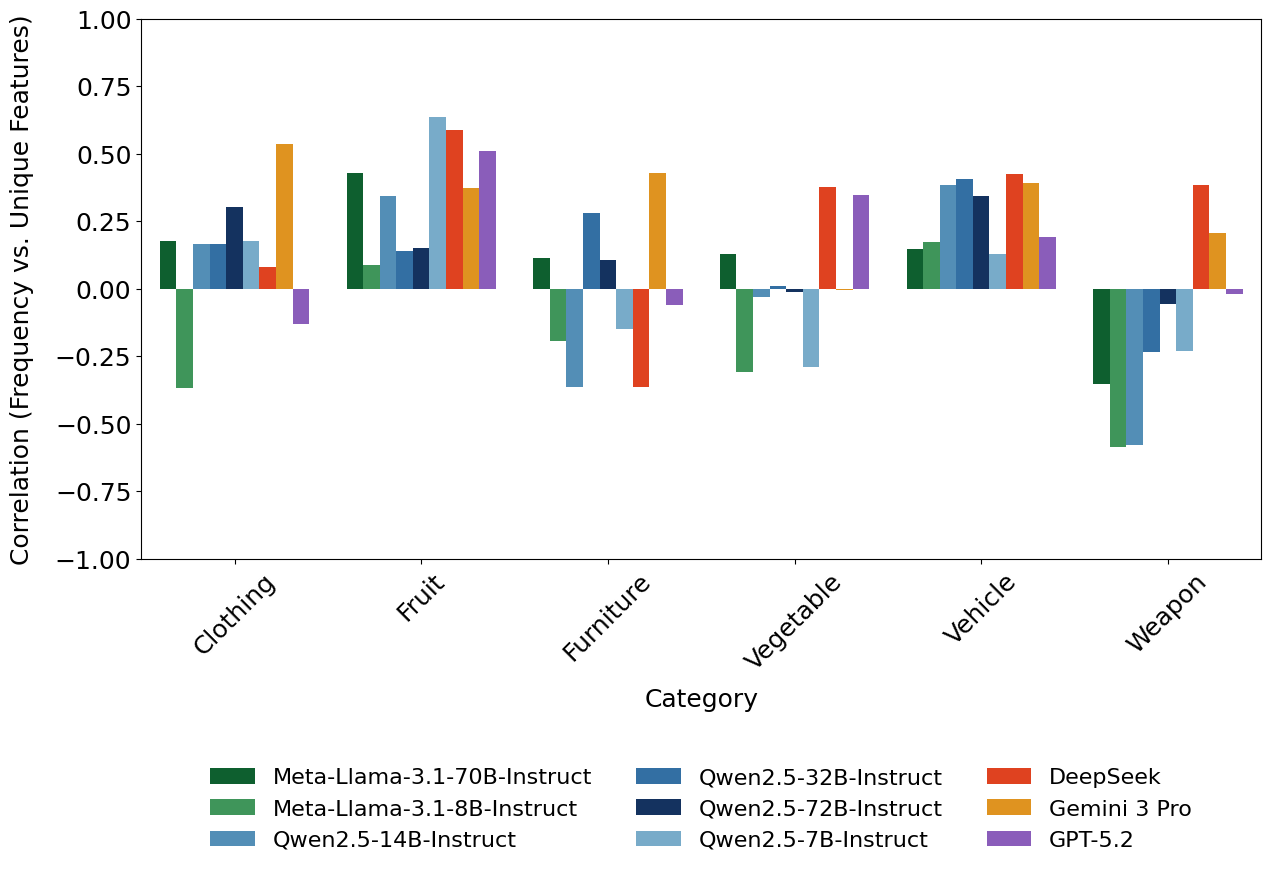

In [ ]:
correlation_attrfreq = (
    unique_attributes_df.groupby(['category', 'model'])
    .apply(lambda x: x['unique_attributes_count'].corr(x['frequency']))
    .reset_index(name='correlation')
)

model_color_map = {
    'Qwen2.5-7B-Instruct': '#6baed6',
    'Qwen2.5-14B-Instruct': '#4292c6',
    'Qwen2.5-32B-Instruct': '#2171b5',
    'Qwen2.5-72B-Instruct': '#08306b',
    'Meta-Llama-3.1-8B-Instruct': '#31a354',
    'Meta-Llama-3.1-70B-Instruct': '#006d2c',
    'DeepSeek': '#ff2e00',
    'Gemini 3 Pro': '#ff9900',
    'GPT-5.2': '#8a4dca'
}

model_name_map = {
    'gpt-5.2': 'GPT-5.2',
    'deepseek-chat': 'DeepSeek',
    'gemini-3-pro': 'Gemini 3 Pro',
}

correlation_attrfreq = correlation_attrfreq.copy()
correlation_attrfreq['model_display'] = correlation_attrfreq['model'].map(
    lambda x: model_name_map.get(x, x)
)

display_palette = {
    model_name_map.get(model, model): color
    for model, color in model_color_map.items()
}

model_order = [
    model_name_map.get(model, model)
    for model in correlation_attrfreq['model'].drop_duplicates()
]

fig, ax = plt.subplots(figsize=(14, 9)) 

sns.barplot(
    data=correlation_attrfreq,
    x='category',
    y='correlation',
    hue='model_display',
    hue_order=model_order,
    palette=display_palette,
    ax=ax
)

ax.set_xlabel('Category', fontsize=18, labelpad=10)
ax.set_ylabel('Correlation (Frequency vs. Unique Features)', fontsize=18, labelpad=15)
ax.set_ylim(-1, 1)

ax.tick_params(axis='x', labelsize=18, rotation=45)
ax.tick_params(axis='y', labelsize=18)

ax.legend(
    fontsize=16,
    loc='upper center',
    bbox_to_anchor=(0.5, -0.35), 
    ncol=3,
    frameon=False
)

plt.subplots_adjust(
    left=0.18,   
    right=0.98,
    top=0.95,
    bottom=0.35 
)

plt.savefig(
    '03_PropertiesFigures/appendix_table_typicality_uniquefeat_correlations.pdf',
    format='pdf',
    bbox_inches='tight'
)

plt.show()

C:\Users\AS\AppData\Local\Temp\ipykernel_20000\2055429921.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
C:\Users\AS\AppData\Local\Temp\ipykernel_20000\2055429921.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
C:\Users\AS\AppData\Local\Temp\ipykernel_20000\2055429921.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
C:\Users\AS\AppData\Local\Temp\ipykernel_20000\2055429921.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
C:\U

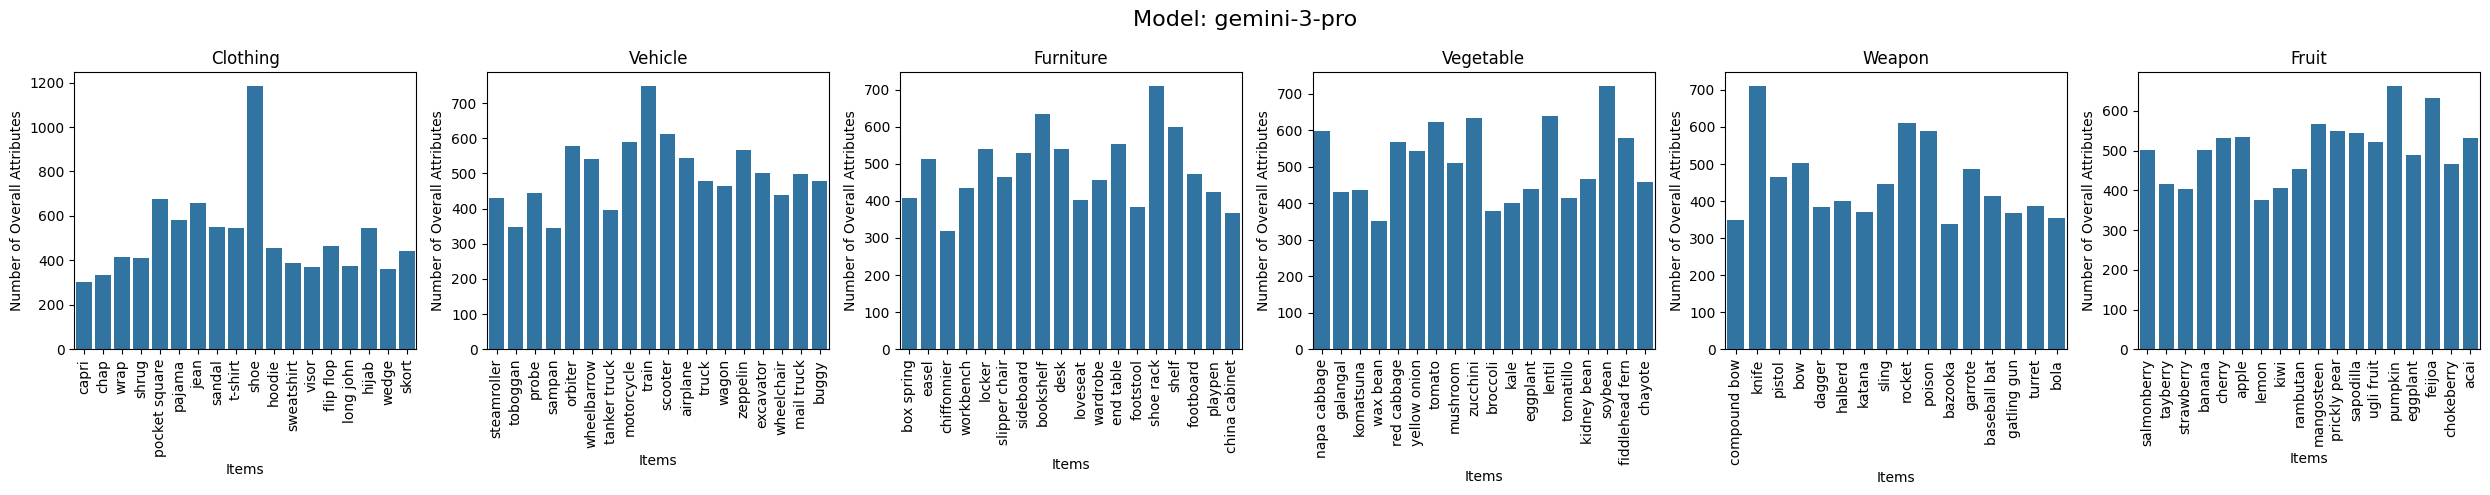

C:\Users\AS\AppData\Local\Temp\ipykernel_20000\2055429921.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
C:\Users\AS\AppData\Local\Temp\ipykernel_20000\2055429921.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
C:\Users\AS\AppData\Local\Temp\ipykernel_20000\2055429921.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
C:\Users\AS\AppData\Local\Temp\ipykernel_20000\2055429921.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
C:\U

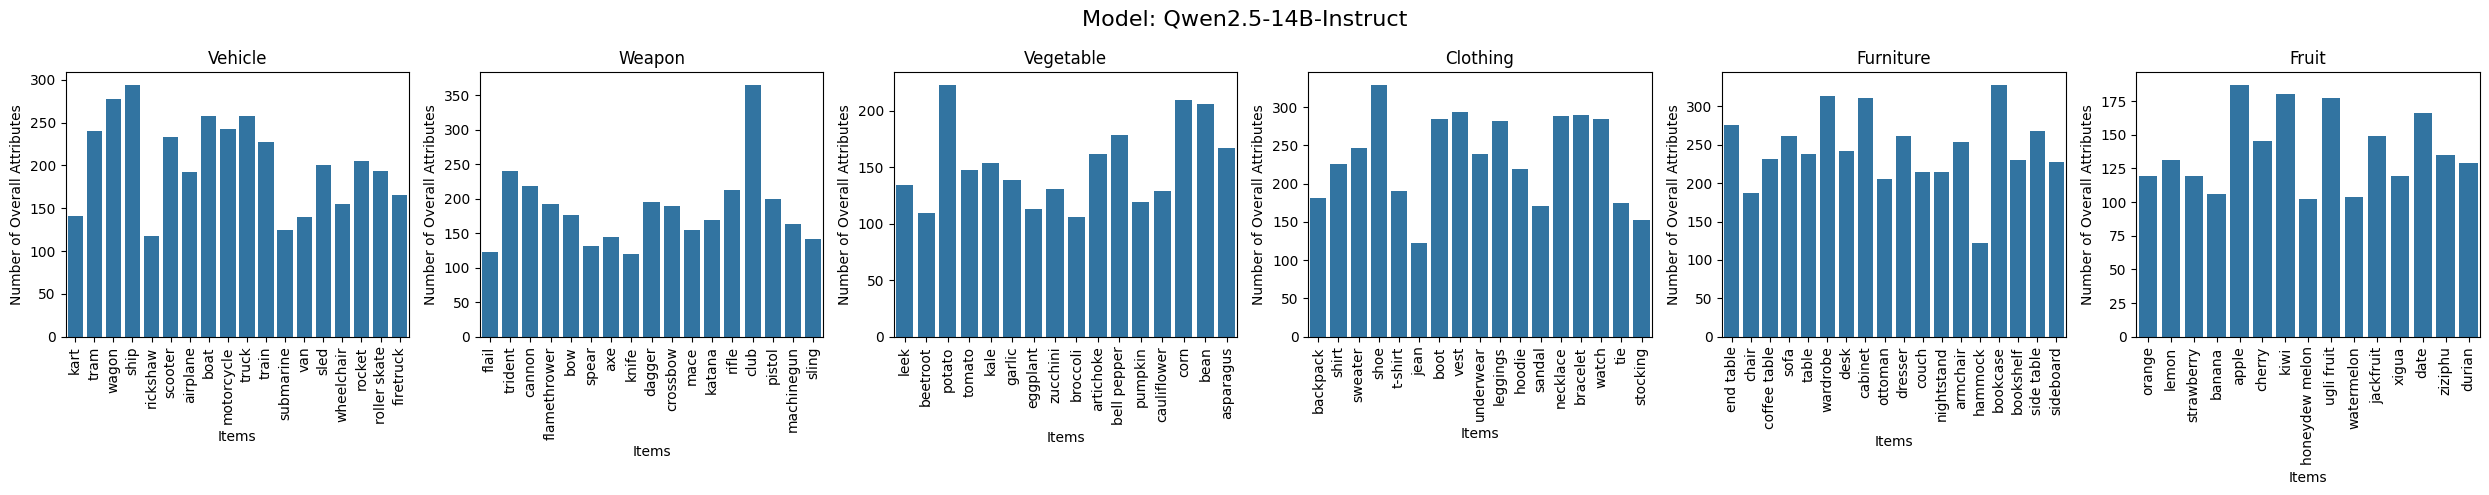

C:\Users\AS\AppData\Local\Temp\ipykernel_20000\2055429921.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
C:\Users\AS\AppData\Local\Temp\ipykernel_20000\2055429921.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
C:\Users\AS\AppData\Local\Temp\ipykernel_20000\2055429921.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
C:\Users\AS\AppData\Local\Temp\ipykernel_20000\2055429921.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
C:\U

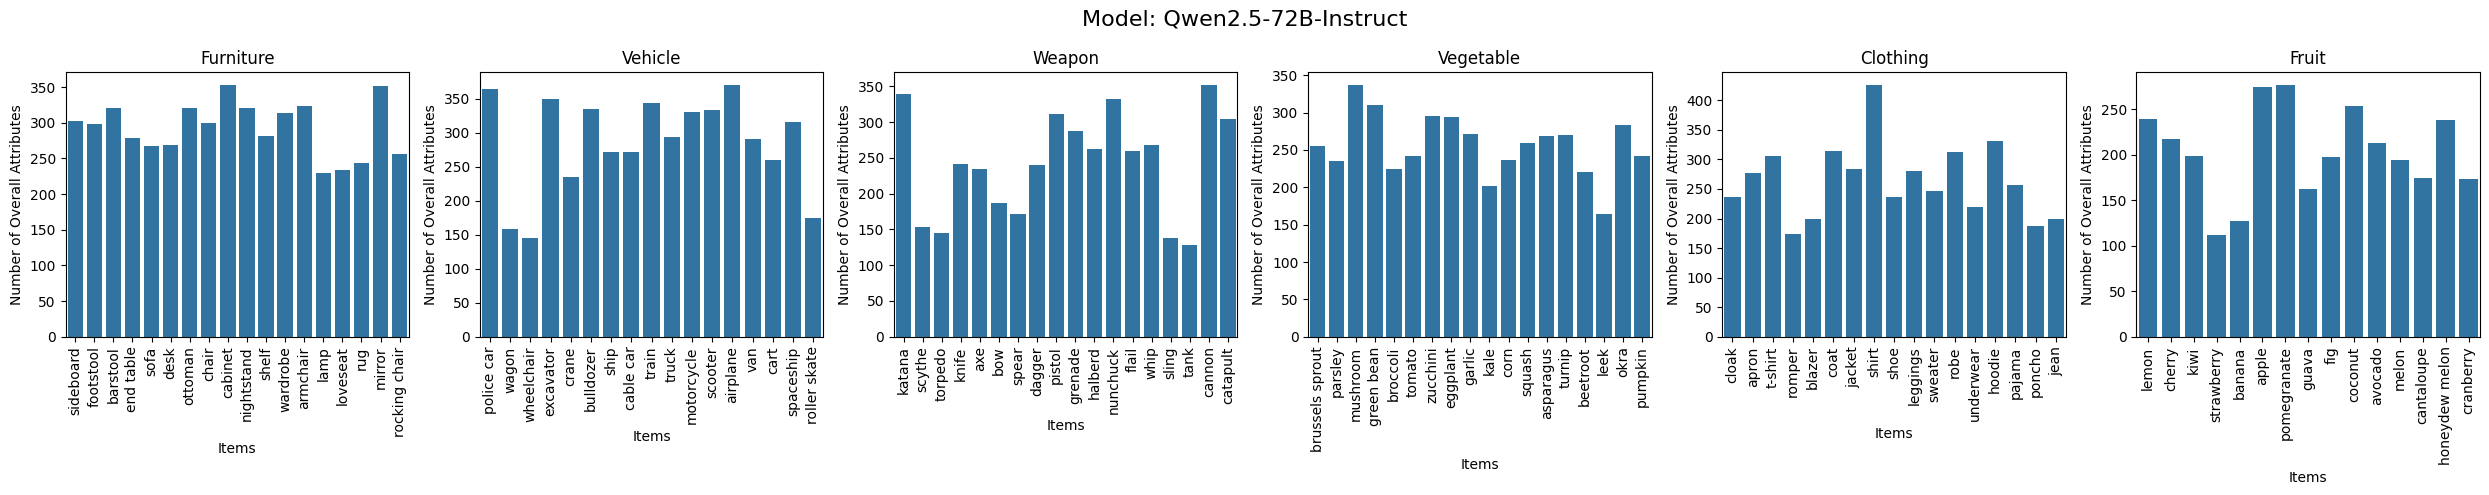

C:\Users\AS\AppData\Local\Temp\ipykernel_20000\2055429921.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
C:\Users\AS\AppData\Local\Temp\ipykernel_20000\2055429921.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
C:\Users\AS\AppData\Local\Temp\ipykernel_20000\2055429921.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
C:\Users\AS\AppData\Local\Temp\ipykernel_20000\2055429921.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
C:\U

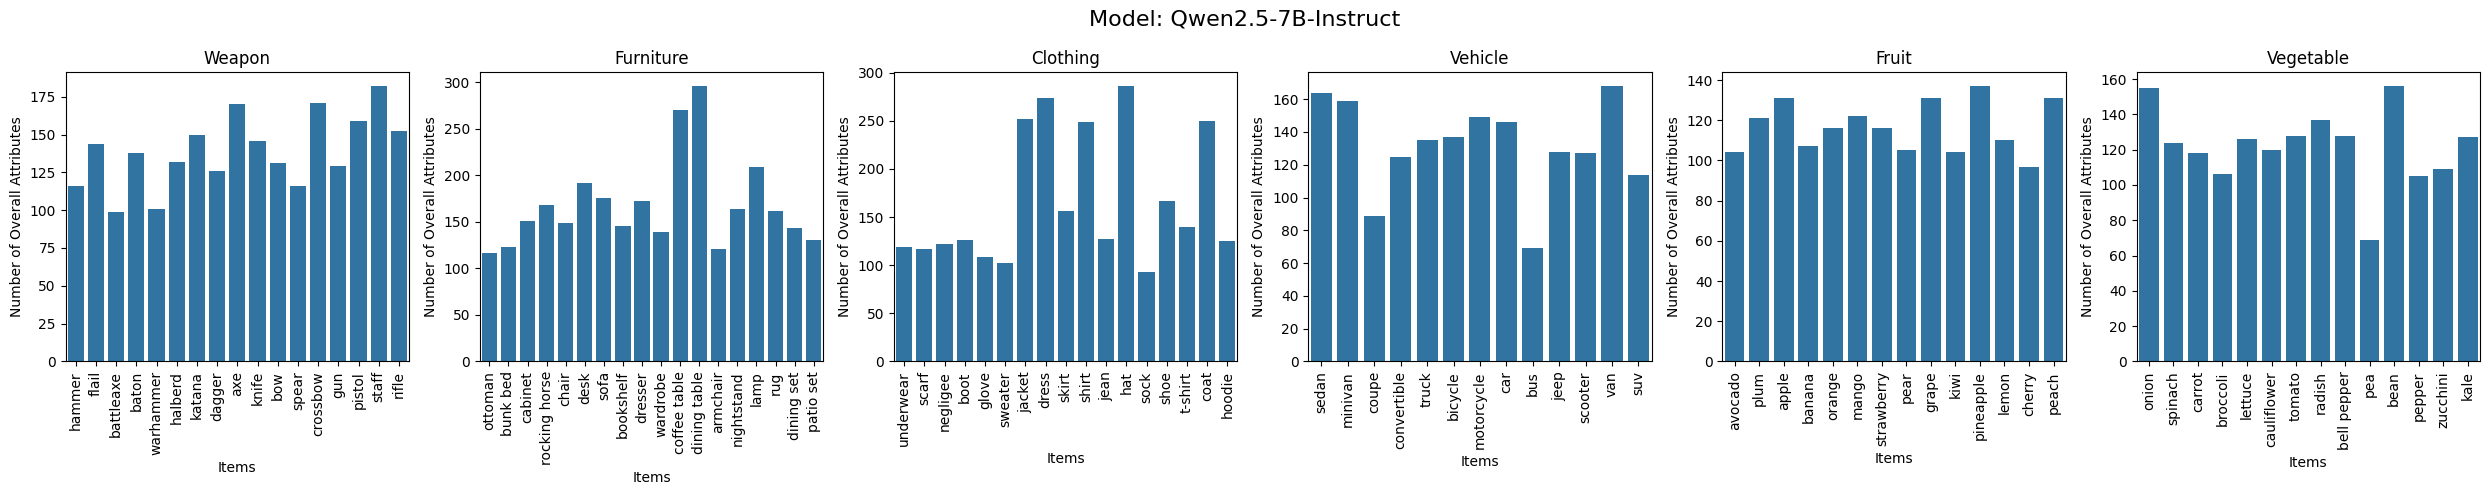

C:\Users\AS\AppData\Local\Temp\ipykernel_20000\2055429921.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
C:\Users\AS\AppData\Local\Temp\ipykernel_20000\2055429921.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
C:\Users\AS\AppData\Local\Temp\ipykernel_20000\2055429921.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
C:\Users\AS\AppData\Local\Temp\ipykernel_20000\2055429921.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
C:\U

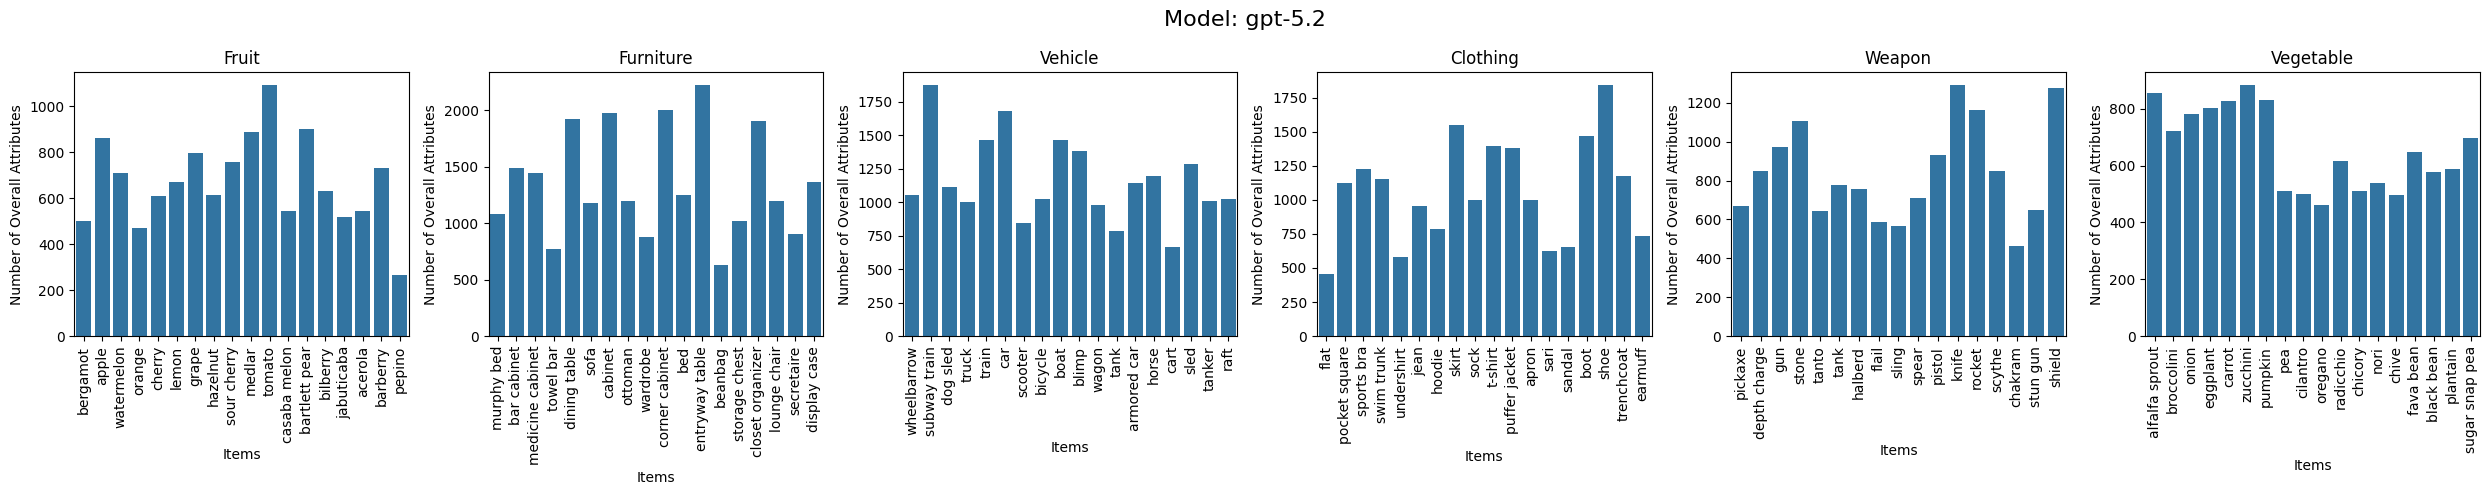

C:\Users\AS\AppData\Local\Temp\ipykernel_20000\2055429921.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
C:\Users\AS\AppData\Local\Temp\ipykernel_20000\2055429921.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
C:\Users\AS\AppData\Local\Temp\ipykernel_20000\2055429921.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
C:\Users\AS\AppData\Local\Temp\ipykernel_20000\2055429921.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
C:\U

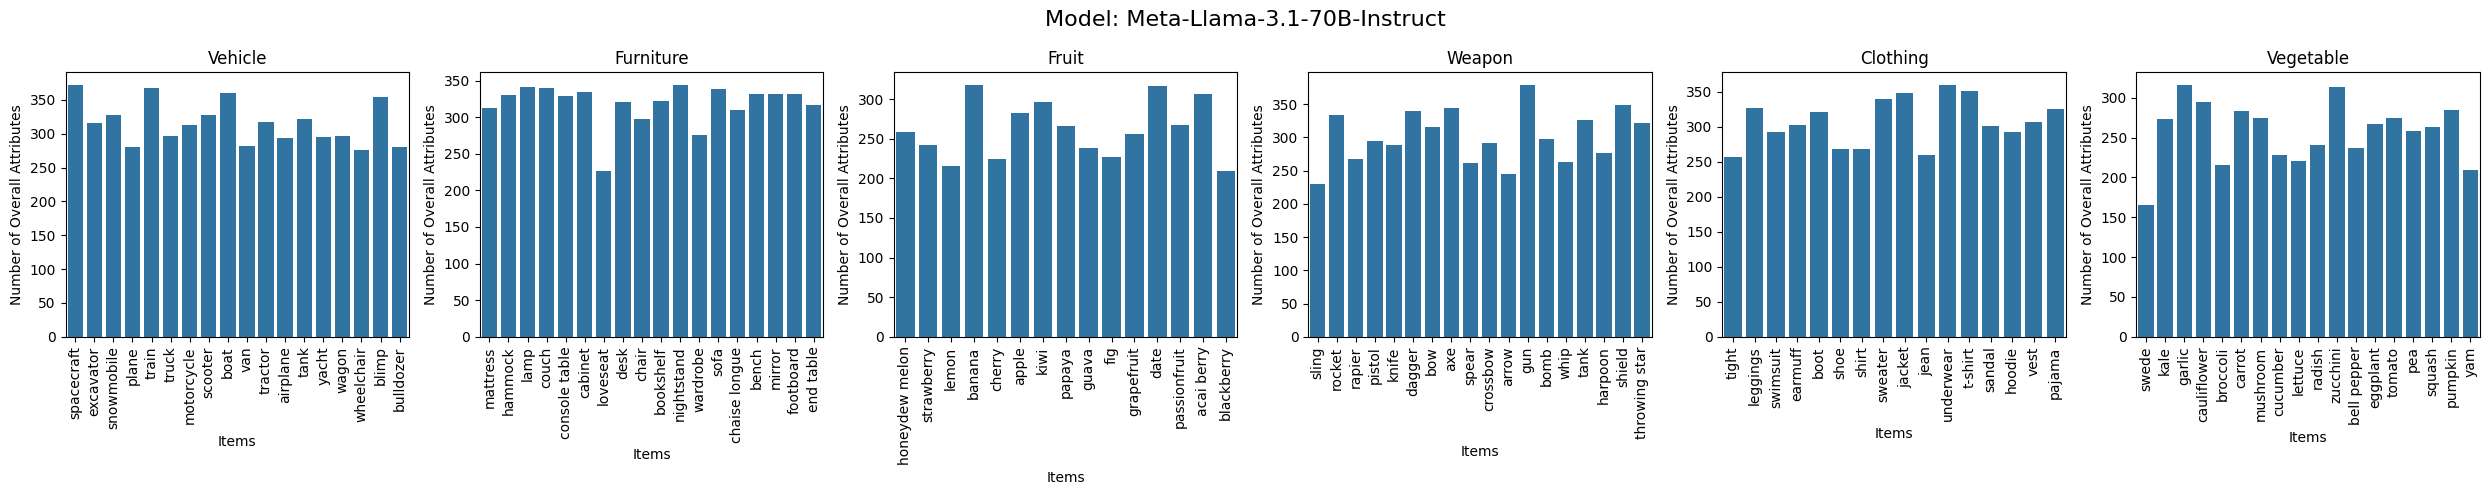

C:\Users\AS\AppData\Local\Temp\ipykernel_20000\2055429921.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
C:\Users\AS\AppData\Local\Temp\ipykernel_20000\2055429921.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
C:\Users\AS\AppData\Local\Temp\ipykernel_20000\2055429921.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
C:\Users\AS\AppData\Local\Temp\ipykernel_20000\2055429921.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
C:\U

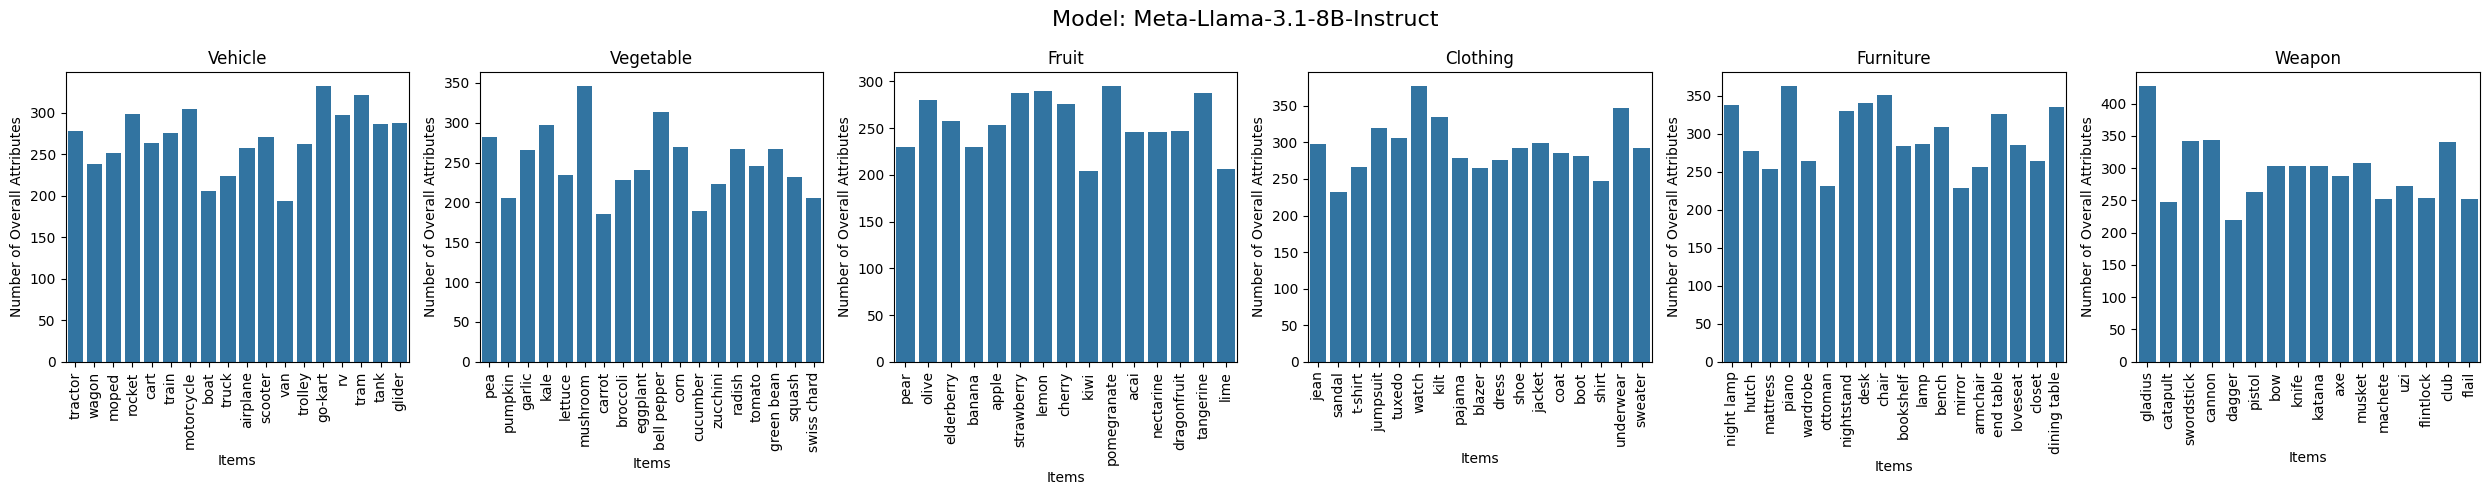

C:\Users\AS\AppData\Local\Temp\ipykernel_20000\2055429921.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
C:\Users\AS\AppData\Local\Temp\ipykernel_20000\2055429921.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
C:\Users\AS\AppData\Local\Temp\ipykernel_20000\2055429921.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
C:\Users\AS\AppData\Local\Temp\ipykernel_20000\2055429921.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
C:\U

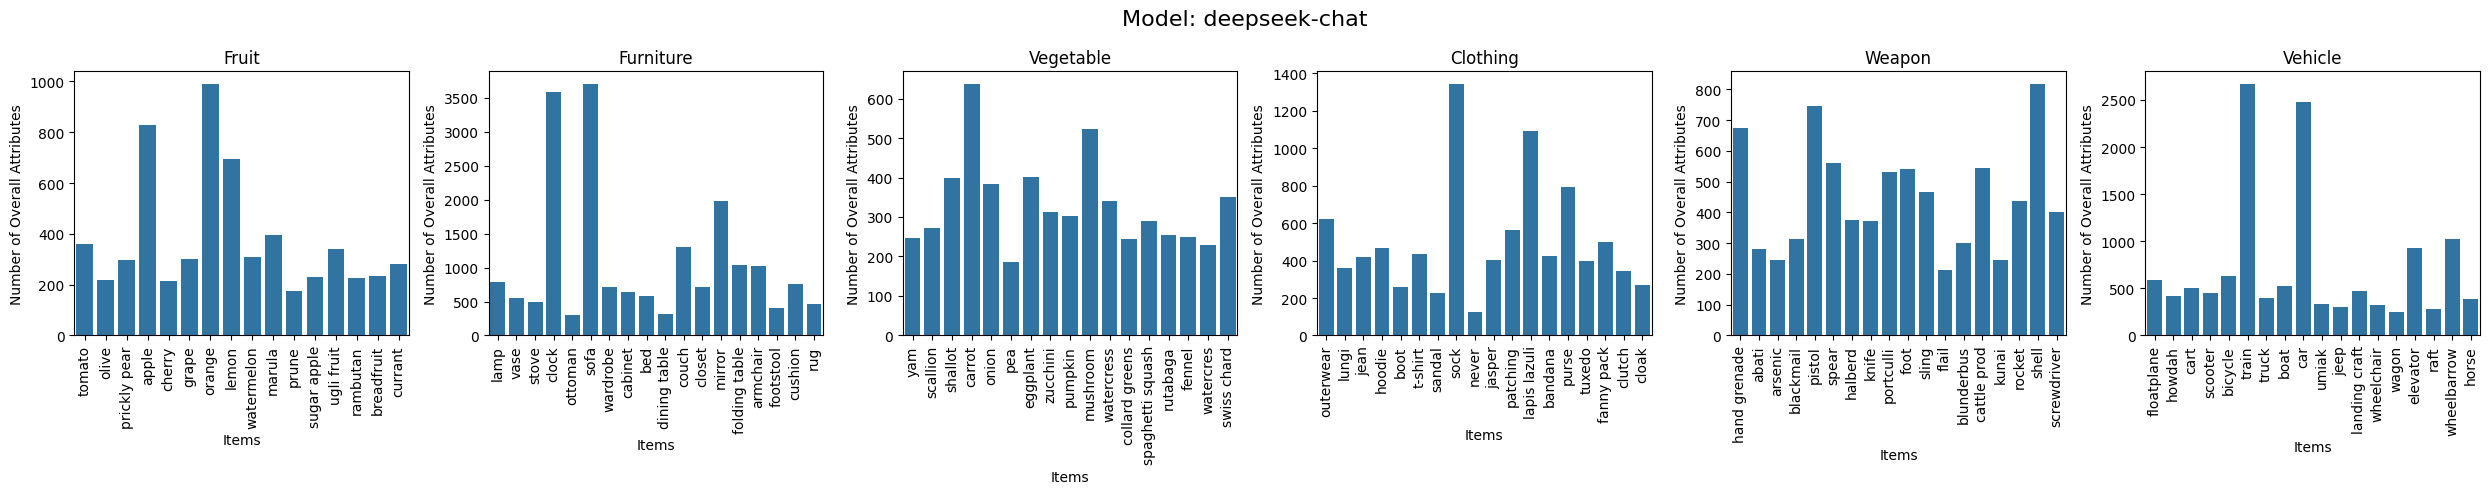

C:\Users\AS\AppData\Local\Temp\ipykernel_20000\2055429921.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
C:\Users\AS\AppData\Local\Temp\ipykernel_20000\2055429921.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
C:\Users\AS\AppData\Local\Temp\ipykernel_20000\2055429921.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
C:\Users\AS\AppData\Local\Temp\ipykernel_20000\2055429921.py:35: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
C:\U

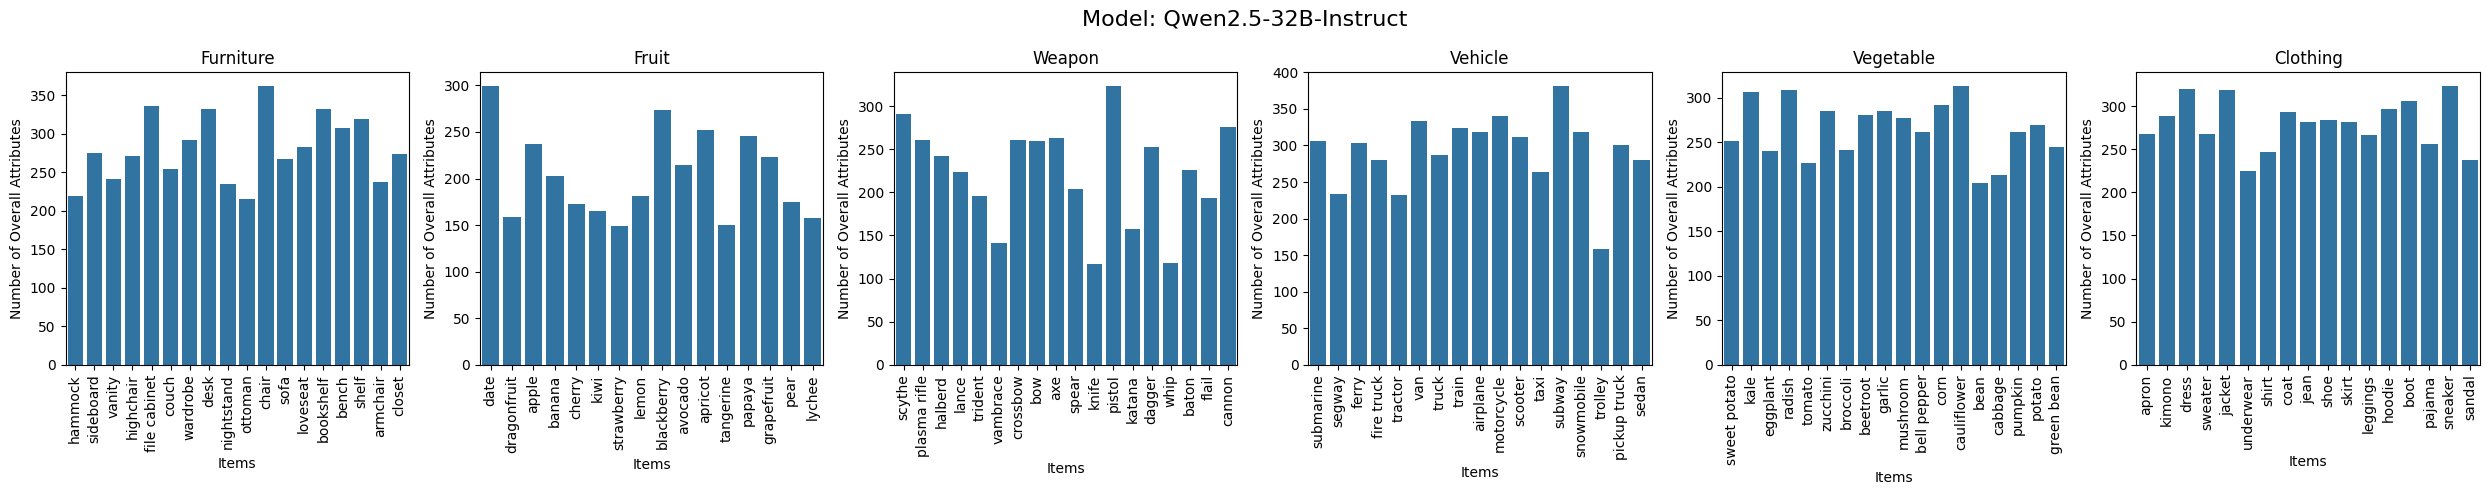

In [ ]:
# Plot number of overall produced attributes for each item

unique_attributes_df['attributes_length'] = unique_attributes_df['attributes'].apply(len)

unique_models = unique_attributes_df['model'].unique()

for selected_model in unique_models:
    
    model_df = unique_attributes_df[unique_attributes_df['model'] == selected_model]

    unique_categories = model_df['category'].unique()

    num_categories = len(unique_categories)
    fig, axes = plt.subplots(nrows=1, ncols=num_categories, figsize=(25, 5), tight_layout=True)

    for ax, category in zip(axes, unique_categories):
        
        category_df = model_df[model_df['category'] == category]

        category_df = category_df.sort_values(by='frequency', ascending=False)

        sns.barplot(data=category_df, x='item', y='attributes_length', ax=ax, order=category_df['item'])
     
        ax.set_title(f'{category}')
        ax.set_xlabel('Items')
        ax.set_ylabel('Number of Overall Attributes')
        ax.set_xticklabels(ax.get_xticklabels(), rotation=90)

    fig.suptitle(f'Model: {selected_model}', fontsize=16)

    plt.show()



C:\Users\AS\AppData\Local\Temp\ipykernel_20000\3047424935.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x['attributes_length'].corr(x['frequency']))


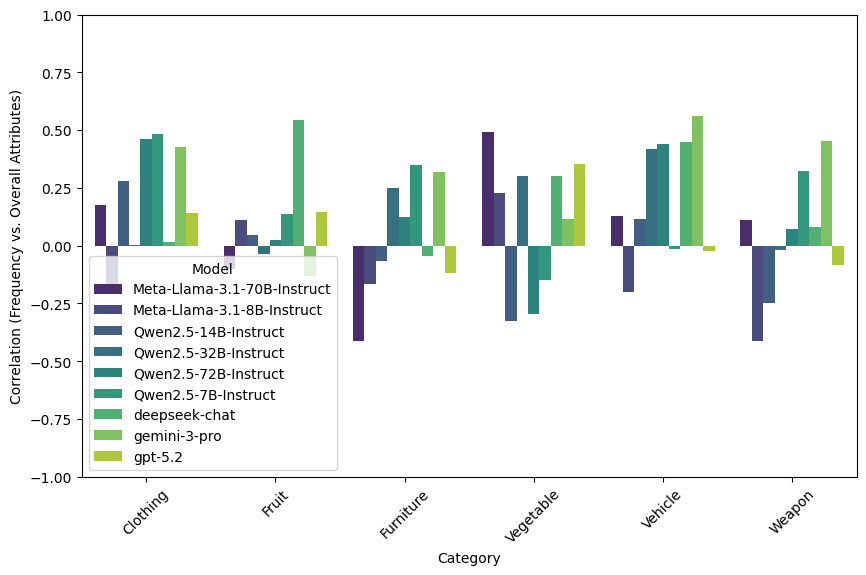

In [ ]:
# Correlation between number of overall outputted attributes and item frequency

unique_attributes_df['attributes_length'] = unique_attributes_df['attributes'].apply(len)

correlation_attrfreq = (
    unique_attributes_df.groupby(['category', 'model'])
    .apply(lambda x: x['attributes_length'].corr(x['frequency']))
    .reset_index(name='correlation')
)

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(data=correlation_attrfreq, x='category', y='correlation', hue='model', palette="viridis")
plt.xlabel('Category')
plt.ylabel('Correlation (Frequency vs. Overall Features)')
plt.tick_params(axis='x', rotation=45)
plt.ylim(-1, 1)
plt.legend(title='Model', loc='lower left')
plt.show()

